# Demo run of the Bayesian code

Goal: estimating per-voxel tissue compartment fractions (`W`) and compartment spectra (`C`) from simulated diffusion-relaxation MRI signal

The model: Each voxel's signal is explained as a mixture of `K` tissue compartments, each with its own characteristic (D, T2) spectrum. A voxel's mixture weights `W` follow a Dirichlet prior with concentration `alpha`. The compartments' spectra `C` are shared across all voxels and are regularized with a Gaussian prior. Signal is compressed via SVD (`R` components) before fitting.

## NNLS initialisation

The optimiser needs an initial estimate of the shared compartment spectra. This notebook uses NNLS initialisation: for each selected voxel, it solves `min ||A f - y||^2` subject to `f >= 0`, producing a non-negative spectrum on the `(D, T2)` grid. The voxel spectra are averaged, clustered into `K` compartments, represented by Gaussian-shaped spectra, and projected into the reduced SVD basis.

The initialised compartments are then passed to the same downstream Bayesian optimisation used for the least-squares and ground-truth comparisons.

**What this notebook shows:**
1. Building the synthetic acquisition and (D, T2) grid
2. Simulating ground-truth compartments, mixture weights and noisy signal
3. Running the optimiser to recover `W` and `C` from the signal alone
4. Evaluating and visualizing recovery accuracy
5. Comparing initialization strategies
6. Sensitivity of recovery to the Dirichlet concentration `alpha`
7. Fixed vs learned `alpha`: separating the `alpha` feedback loop from the (C, W) ambiguity
8. A recovery test on a small synthetic case with known answers
9. Estimating M0 and sigma2 as well, instead of giving their true values
10. Where the automated test suite lives and how to run it

All core functions live in `create_grid.py`, `optimiser_alpha_gamma.py` and `plotting.py` and are unit-tested in `tests/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from create_grid import *
from optimiser_alpha_gamma import *
from plotting import *

## 1. Acquisition and compartment grid

We define a grid of diffusion coefficients `D` and T2 relaxation times and an acquisition protocol over `b`-values and echo times `TE`. The forward model `A` maps a (D, T2) spectrum to a noiseless signal via

$$A[i, j] = \exp(-b_i D_j)\exp(-TE_i / T2_j)$$

`A` is then compressed with an SVD to `R` components (`U`, `s`, `V`), which is what the optimiser actually fits against 

In [2]:
# (D, T2) grid and acquisition protocol
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.2, 20.0, 2.0, 150.0, 20, 20
Bmin, Bmax, nB, TEmin, TEmax, nTE = 0.0, 4.0, 8, 20.0, 180.0, 8

R, K = 8, 3           # SVD components, number of tissue compartments
n_voxels = 1000
alpha_true = 3.0       # Dirichlet concentration for the true mixture weights
sigma_true = 0.002      # measurement noise std
eps = 1e-10

# three ground-truth compartments, each a Gaussian blob in (D, T2) space
D_means = [0.4, 0.9, 1.6]
D_stds = [0.10, 0.12, 0.16]
T2_means = [90, 55, 120]
T2_stds = [15, 10, 18]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)
b_vals = np.linspace(Bmin, Bmax, nB)
TE_vals = np.linspace(TEmin, TEmax, nTE)
A = create_A_matrix(D_grid, T2_grid, Bmin, Bmax, nB, TEmin, TEmax, nTE)
U, s, V_mat = apply_SVD_to_A(A, R)

print(f"A: {A.shape} is compressed to U: {U.shape}, s: {s.shape}, V: {V_mat.shape}")

A: (64, 400) is compressed to U: (64, 8), s: (8,), V: (400, 8)


## 2. Simulating ground-truth data

We build the true compartment spectra `C_true`, draw per-voxel mixture weights `W_true` from a Dirichlet(`alpha_true`) prior, draw a per-voxel scale `M0_true` and simulate the noisy signal `Y`.

A fixed `rng = np.random.default_rng(seed)` is threaded through every random draw, so the whole simulation is reproducible from one seed.

! Runtime note: This demo is configured to run on 1000 voxels and may take a while, especially in the initialisation comparisons and parameter sweeps. To make a quick test run, change `n_voxels = 1000` in the acquisition/grid setup cell above to a smaller value, such as `100` or `20`. The same value is then used throughout the notebook.

In [3]:
rng = np.random.default_rng(1)

C_true = create_gaussian_compartments(D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds)
W_true = create_W_true(K, n_voxels, alpha_true, rng)
M0_true = create_M0_true(0.7, 1.3, n_voxels, rng)
Y = create_signal(A, C_true, W_true, M0_true, sigma_true, rng)

C_small_true = np.diag(s) @ V_mat.T @ C_true    # ground truth in the compressed (R, K) space
sigma2_true = sigma_true ** 2

print(f"C_true: {C_true.shape}, W_true: {W_true.shape}, Y (signal): {Y.shape}")
print(f"W_true columns sum to 1 (valid simplex): {np.allclose(W_true.sum(axis=0), 1.0)}")

C_true: (400, 3), W_true: (3, 1000), Y (signal): (64, 1000)
W_true columns sum to 1 (valid simplex): True


## 3. Initialising and running the optimiser

We start from a data-driven initialisation: random mixture weights `W0`, then a least-squares fit of `C_small0` given `W0`. `run_optimisation` then alternates block-coordinate updates of `W`, `C_small` and `alpha` for a fixed number of iterations (`n_iter`), never using the ground truth at any point.

In [4]:
n_iter = 150

W0, _ = define_initial_W_and_m(K, n_voxels, rng, alpha_init=5.0)
C_small0 = define_initial_C_small(Y, U, W0, M0_true, K)
lam0 = define_initial_lambda(C_small0, R, K)

W_est, _, C_small_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = run_optimisation(
    Y, U, C_small0, M0_true, K, R, eps, n_iter, sigma2_true, alpha=5.0, lam=lam0, W=W0,
    bound_eps=1e-2,
    update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True,
    verbose_every=n_iter,   # only print the first iteration
)

print(f"\nfinal loss: {losses[-1]:.2f}   final fit_err: {fit_errs[-1]:.5f}   alpha_est: {alpha_est:.2f} (true: {alpha_true})")

iter 0: loss=1893386.2819, fit_err=15.167376, sigma2=0.000004, lam=3.4694, alpha=0.3248

final loss: 31669.74   final fit_err: 0.26177   alpha_est: 3.35 (true: 3.0)


## 4. Results

Since compartments are exchangeable (the optimiser has no notion of "compartment 1, 2, 3" ordering), a correct solution can recover them in a different order than the ground truth. `matched_errors` finds the best matching permutation before computing error, so the reported numbers reflect true recovery accuracy, not label mismatch.

matched W MAE:       0.0737
matched C_small MAE: 0.0389


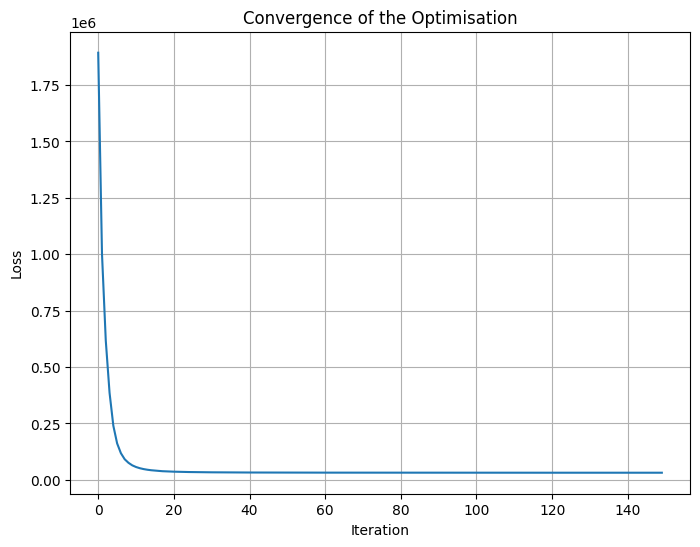

In [5]:
W_mae, C_mae = matched_errors(C_small_true, C_small_est, W_true, W_est)
print(f"matched W MAE:       {W_mae:.4f}")
print(f"matched C_small MAE: {C_mae:.4f}")

plot_loss_curve(losses)

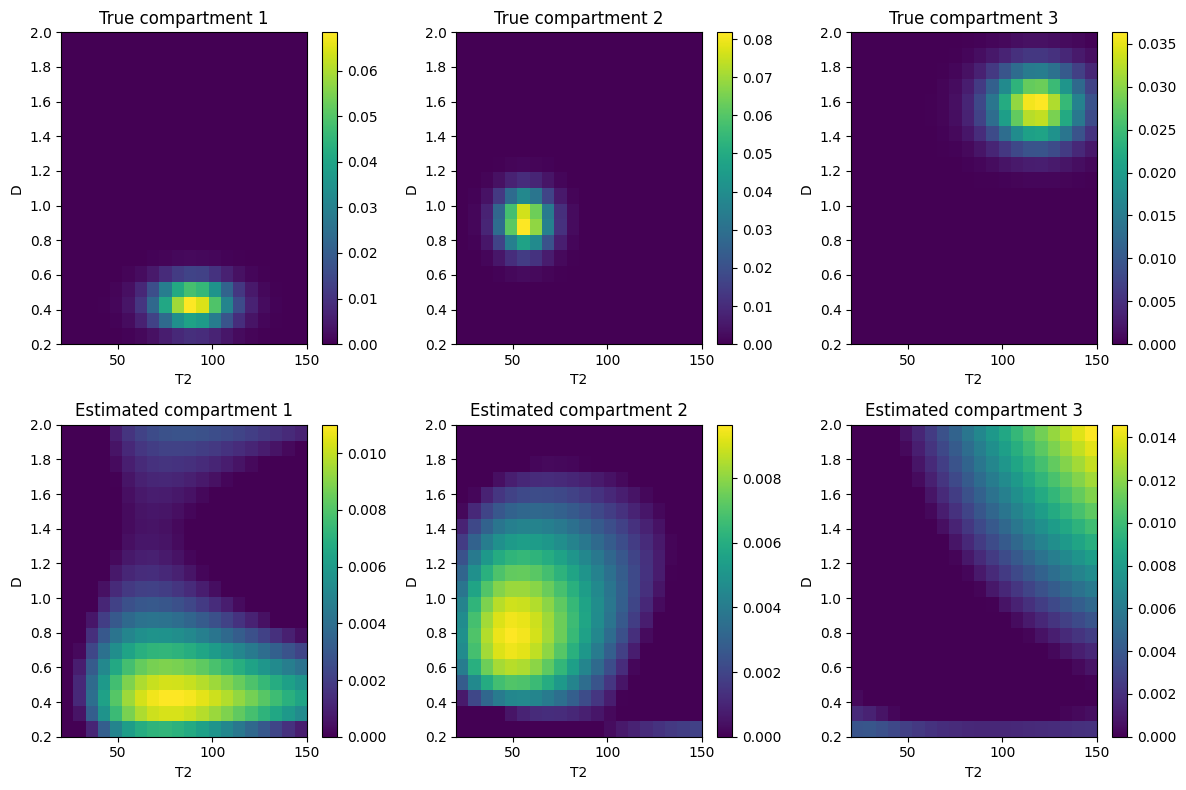

In [6]:
C_est = estimate_C(V_mat, s, C_small_est)
plot_compartment_comparison(C_true, C_est, K, nD, nT2, D_vals, T2_vals)

## 5. Comparing initialisation strategies

How much does the starting point matter? We compare:

- **GT-init:** `C_small` initialised at the ground truth
- **Lstsq-init:** the data-driven least-squares initialisation used above, with no knowledge of the truth
- **NNLS-init:** non-negative least-squares spectra from the selected voxels, clustered into `K` Gaussian compartments

All three initialisations are passed to the same downstream optimiser. Only the starting value of `C_small` changes.

The NNLS initialisation uses a representative subset of voxels to keep this demo reasonably quick. The subset size is controlled in the code cell below.

In [7]:
n_iter = 150
W0, _ = define_initial_W_and_m(K, n_voxels, rng, alpha_init=5.0)
C_small0 = define_initial_C_small(Y, U, W0, M0_true, K)
lam0 = define_initial_lambda(C_small0, R, K)

# Use a representative subset for the expensive NNLS initialiser, the downstream optimiser still runs on all n_voxels.
init_voxel_idx = np.linspace(0, n_voxels - 1, 50, dtype=int).tolist()


def run_with_init(C_small_init, label):
    lam_init = define_initial_lambda(C_small_init, R, K)
    W_i, _, C_small_i, alpha_i, *_ = run_optimisation(
        Y, U, C_small_init, M0_true, K, R, eps, n_iter, sigma2_true, alpha=5.0, lam=lam_init, W=W0,
        bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
        update_M0_flag=False, update_C_flag=True,
        verbose_every=n_iter + 1,
    )
    W_mae_i, C_mae_i = matched_errors(C_small_true, C_small_i, W_true, W_i)
    print(f"{label:10s}  W_mae={W_mae_i:.4f}  C_mae={C_mae_i:.4f}  alpha_est={alpha_i:.2f}")

run_with_init(C_small_true.copy(), "GT-init")
run_with_init(C_small0.copy(), "Lstsq-init")

C_small0_nnls = define_initial_C_small_NNLS(
    Y, A, s, V_mat, init_voxel_idx, K, D_vals, T2_vals, Dmin, Dmax, T2min, T2max, nD, nT2,
)
run_with_init(C_small0_nnls, "NNLS-init")

iter 0: loss=31500.8100, fit_err=0.261699, sigma2=0.000004, lam=2.9989, alpha=3.0262
GT-init     W_mae=0.0062  C_mae=0.0055  alpha_est=3.40
iter 0: loss=1429015.1901, fit_err=11.453286, sigma2=0.000004, lam=3.4695, alpha=0.2935
Lstsq-init  W_mae=0.0321  C_mae=0.0152  alpha_est=2.57
iter 0: loss=33852.8840, fit_err=0.278810, sigma2=0.000004, lam=3.0117, alpha=2.3357
NNLS-init   W_mae=0.0210  C_mae=0.0100  alpha_est=2.99


## 6. Sensitivity to the Dirichlet distribution parameter `alpha`

`alpha` controls how "pure" (few dominant compartments) vs. "mixed" (evenly spread) the true voxel weights are. Lower `alpha` means sparser, more extreme mixtures while higher `alpha` means weights closer to uniform. We check how well the optimiser recovers `alpha` itself and `W`, across a small grid of true values and initial guesses.

In [8]:
alpha_true_values = [1.5, 5.0]
alpha_init_values = [1.5, 5.0]
n_iter_sweep = 200

for a_true in alpha_true_values:
    rng_sweep = np.random.default_rng(1)
    W_true_s = create_W_true(K, n_voxels, a_true, rng_sweep)
    Y_s = create_signal(A, C_true, W_true_s, M0_true, sigma_true, rng_sweep)

    for a_init in alpha_init_values:
        W0_s, _ = define_initial_W_and_m(K, n_voxels, rng_sweep, alpha_init=a_init)
        C_small0_s = define_initial_C_small(Y_s, U, W0_s, M0_true, K)
        lam0_s = define_initial_lambda(C_small0_s, R, K)

        W_est_s, _, C_small_est_s, alpha_est_s, *_ = run_optimisation(
            Y_s, U, C_small0_s, M0_true, K, R, eps, n_iter_sweep, sigma2_true,
            alpha=a_init, lam=lam0_s, W=W0_s,
            bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
            update_M0_flag=False, update_C_flag=True,
            verbose_every=n_iter_sweep + 1,
        )
        W_mae_s, _ = matched_errors(C_small_true, C_small_est_s, W_true_s, W_est_s)
        print(f"{'alpha_true':>10} {'alpha_init':>10} {'alpha_est':>10} {'W_mae':>8}")
        print(f"{a_true:10.2f} {a_init:10.2f} {alpha_est_s:10.2f} {W_mae_s:8.4f}")

iter 0: loss=2584317.9048, fit_err=20.699132, sigma2=0.000004, lam=3.4540, alpha=0.2672
alpha_true alpha_init  alpha_est    W_mae
      1.50       1.50       1.73   0.0235
iter 0: loss=2769061.6806, fit_err=22.174192, sigma2=0.000004, lam=3.4502, alpha=0.3027
alpha_true alpha_init  alpha_est    W_mae
      1.50       5.00       1.89   0.0485
iter 0: loss=1102542.6159, fit_err=8.844258, sigma2=0.000004, lam=3.4401, alpha=0.2783
alpha_true alpha_init  alpha_est    W_mae
      5.00       1.50       3.59   0.0339
iter 0: loss=1225250.6838, fit_err=9.820985, sigma2=0.000004, lam=3.4398, alpha=0.3347
alpha_true alpha_init  alpha_est    W_mae
      5.00       5.00       3.99   0.0655


## 7. Fixed vs learned `alpha`

Is the error coming from the `alpha` feedback loop (W drifts to uniform -> fitted `alpha` goes up -> W pulled harder to uniform), or from (C, W) ambiguity (many C, W pairs fit the signal equally well)?

For each `alpha_true` and each C initialisation (GT, Lstsq, NNLS) we run the optimiser twice: once learning `alpha` (starting at 5.0), and once with `alpha` fixed at the true value. If fixing `alpha` doesn't reduce the W error, the feedback loop isn't the problem. We also print the C error of the initialisation itself, to see how good each starting point is.

iter 0: loss=32557.0099, fit_err=0.266693, sigma2=0.000004, lam=2.9989, alpha=1.5145
iter 0: loss=32554.1470, fit_err=0.266646, sigma2=0.000004, lam=2.9989, alpha=1.5000
alpha_true= 1.5  GT      C_mae init=0.0000  |  learned: W_mae=0.0041 C_mae=0.0025 alpha_est=1.62  |  fixed: W_mae=0.0039 C_mae=0.0024


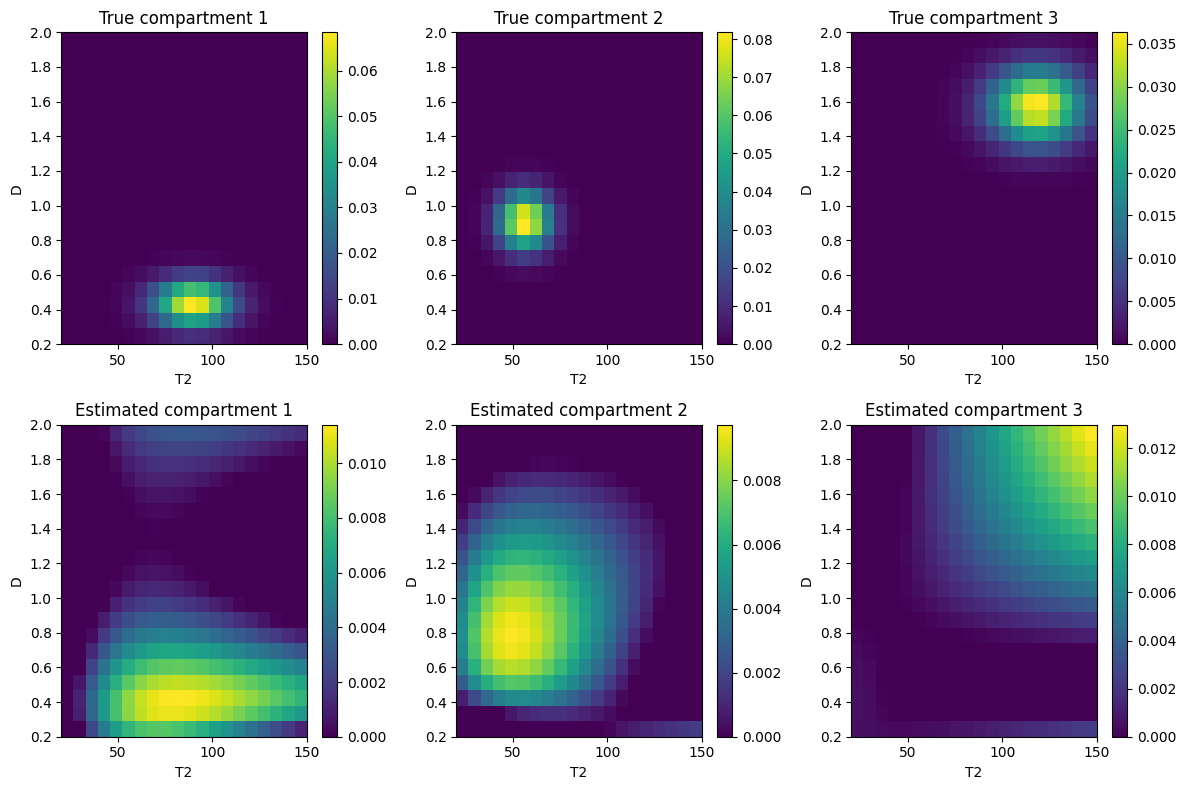

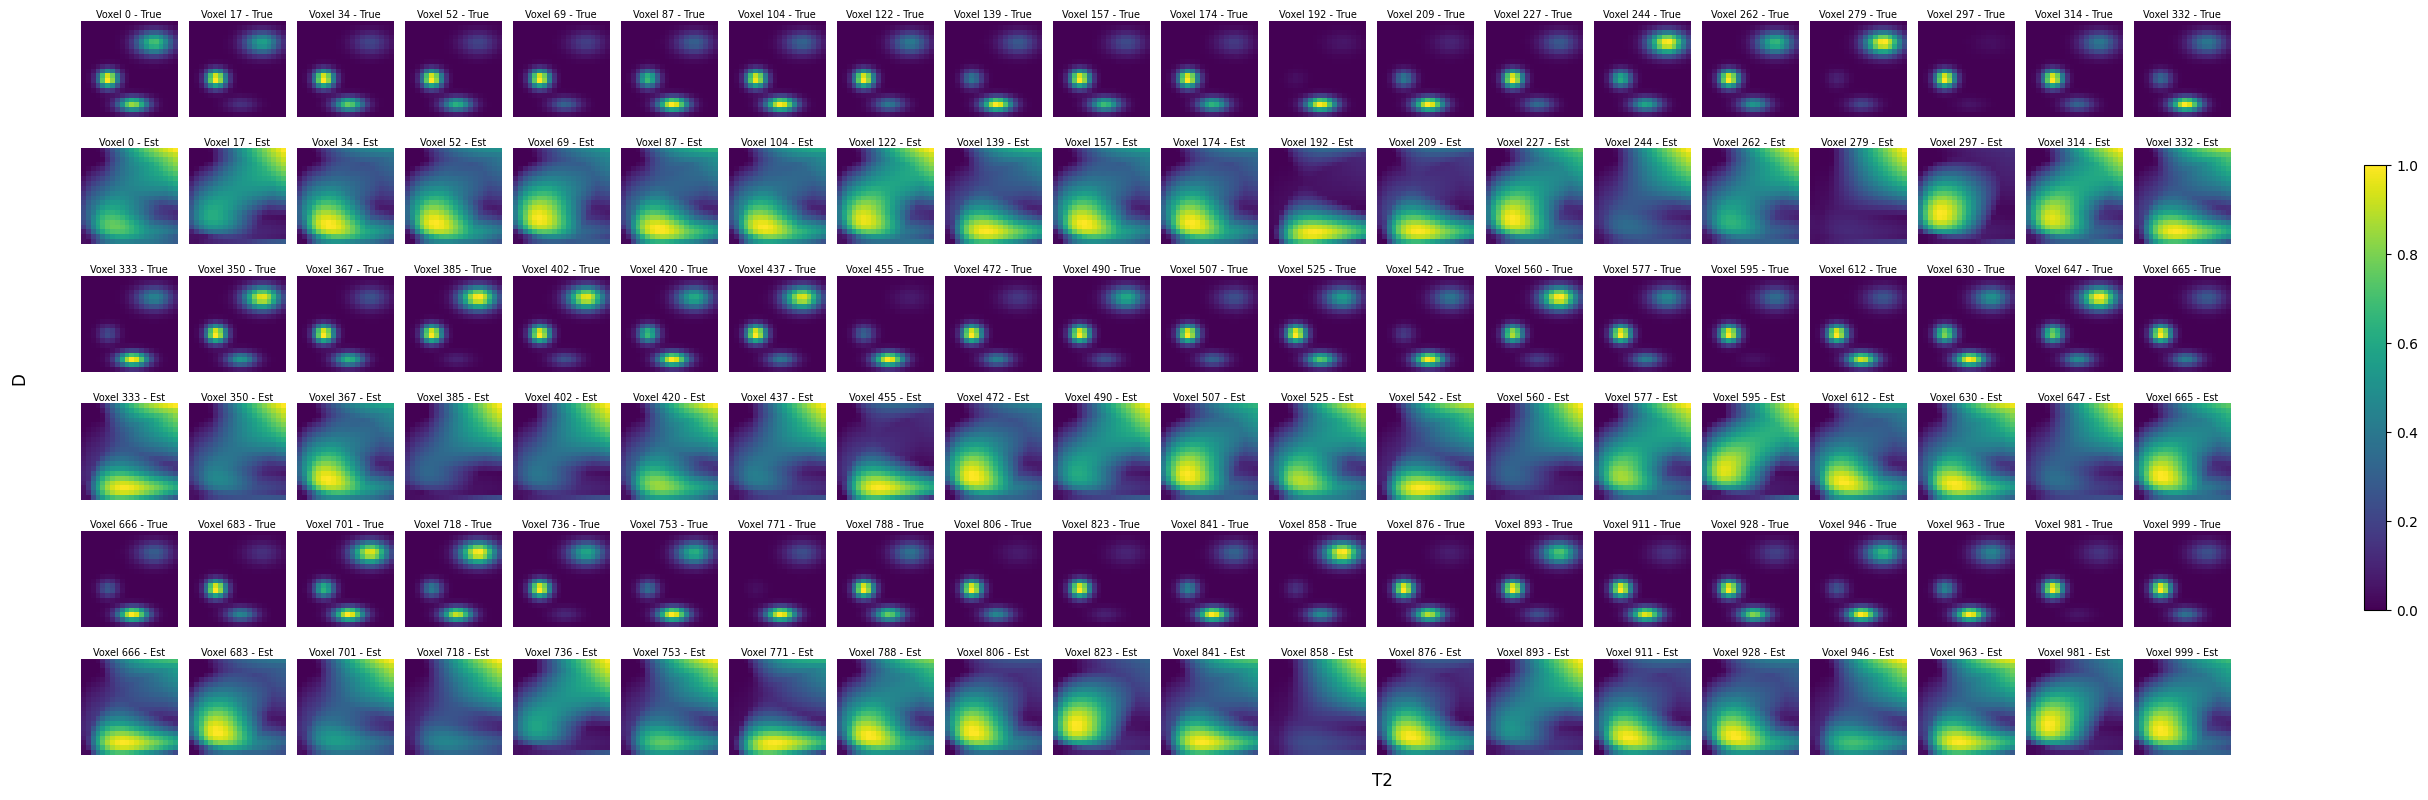

iter 0: loss=6000167.6979, fit_err=48.021453, sigma2=0.000004, lam=3.4537, alpha=0.3282
iter 0: loss=6026080.1985, fit_err=48.195968, sigma2=0.000004, lam=3.4537, alpha=1.5000
alpha_true= 1.5  Lstsq   C_mae init=0.1121  |  learned: W_mae=0.0310 C_mae=0.0143 alpha_est=1.69  |  fixed: W_mae=0.0286 C_mae=0.0130


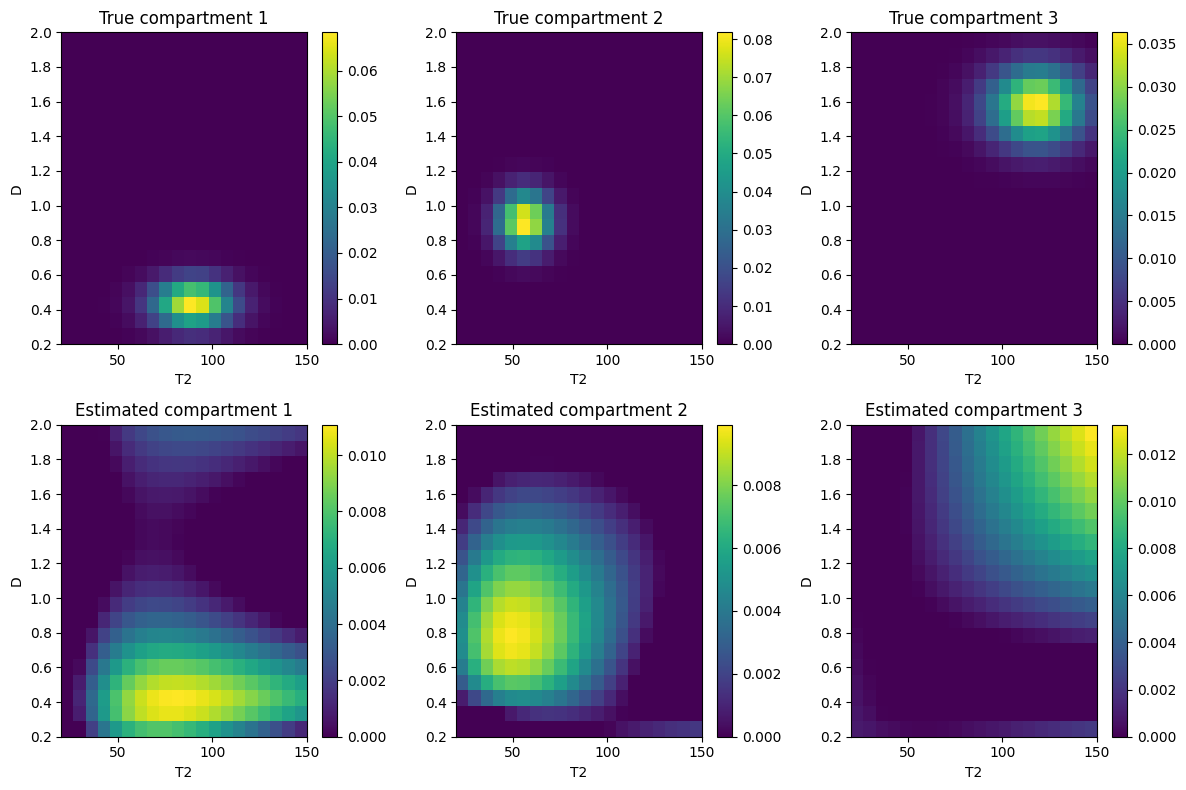

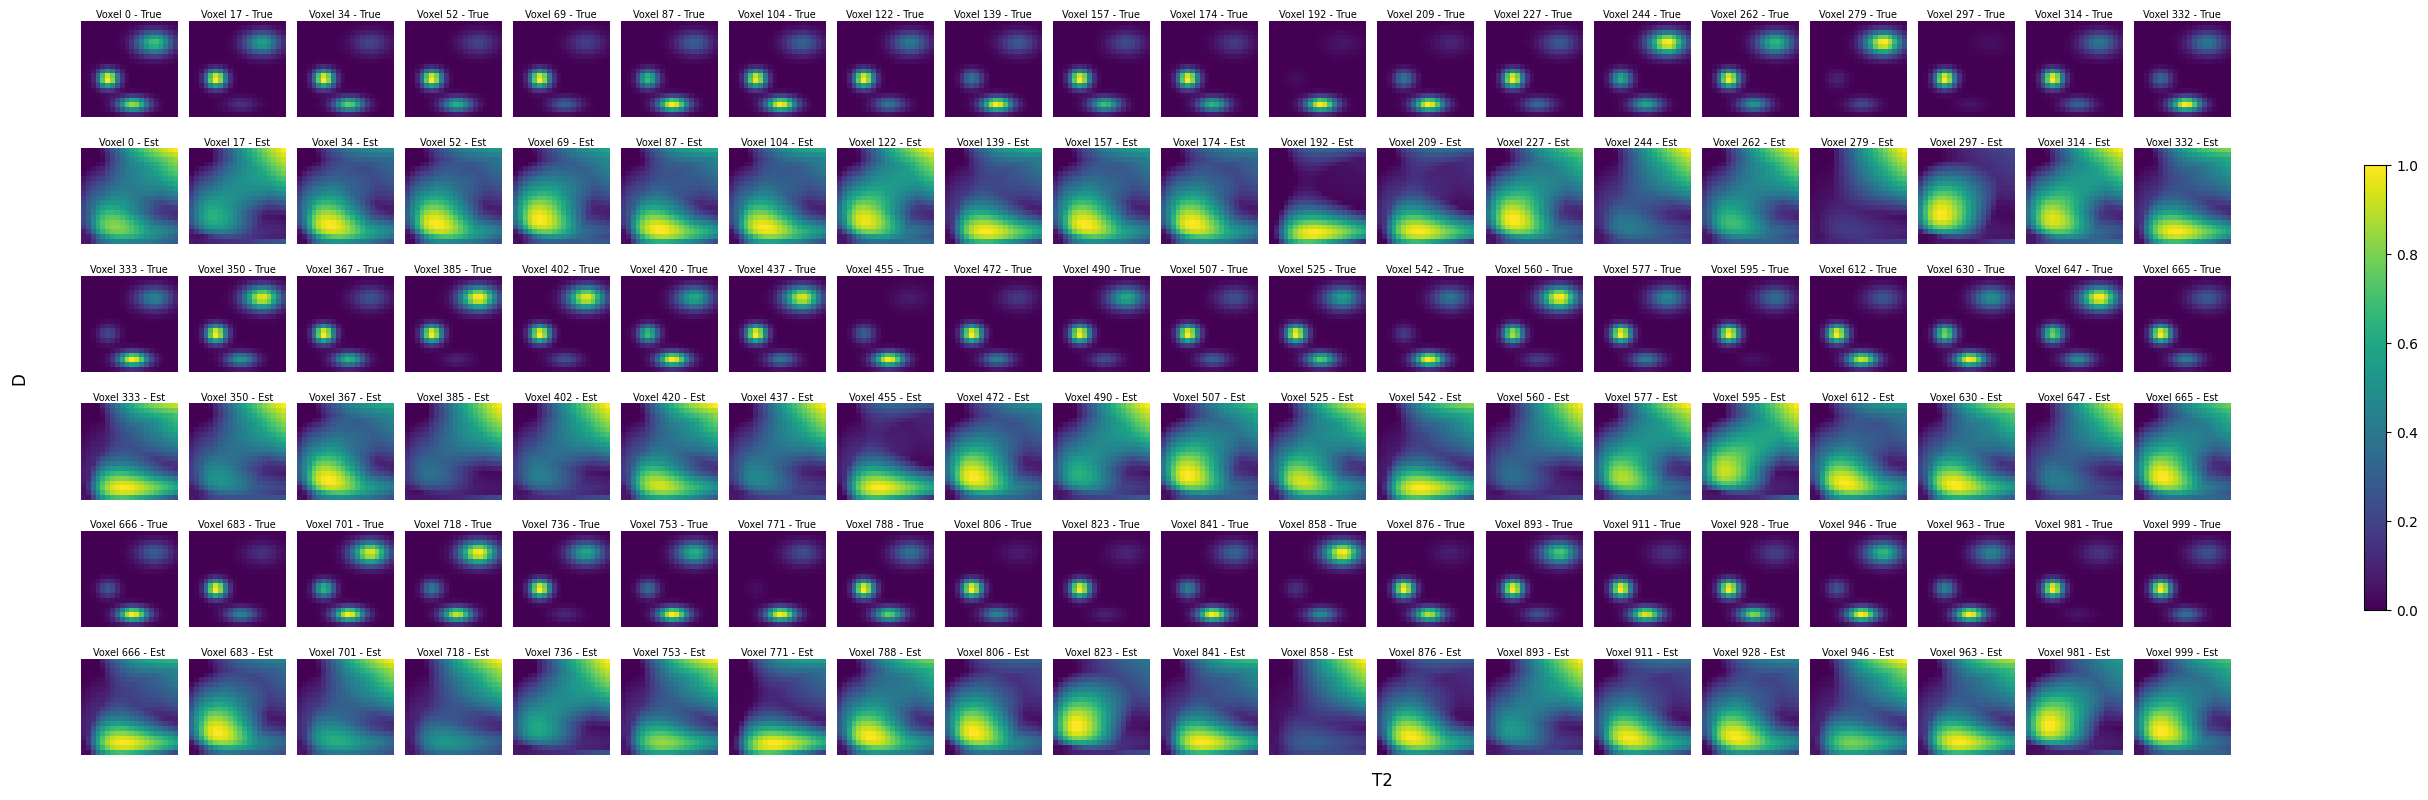

iter 0: loss=46025.3301, fit_err=0.373653, sigma2=0.000004, lam=3.0843, alpha=1.0391
iter 0: loss=46415.3758, fit_err=0.375842, sigma2=0.000004, lam=3.0843, alpha=1.5000
alpha_true= 1.5  NNLS    C_mae init=0.0148  |  learned: W_mae=0.0209 C_mae=0.0084 alpha_est=1.58  |  fixed: W_mae=0.0209 C_mae=0.0084


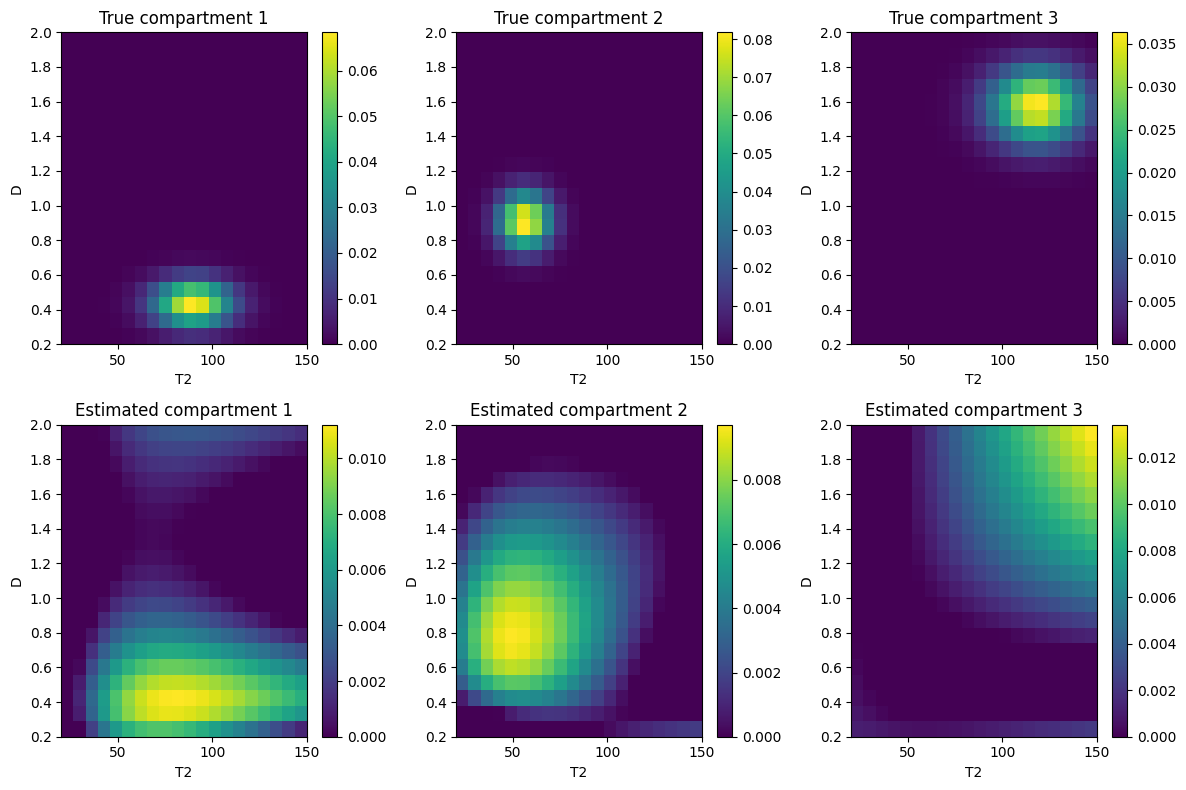

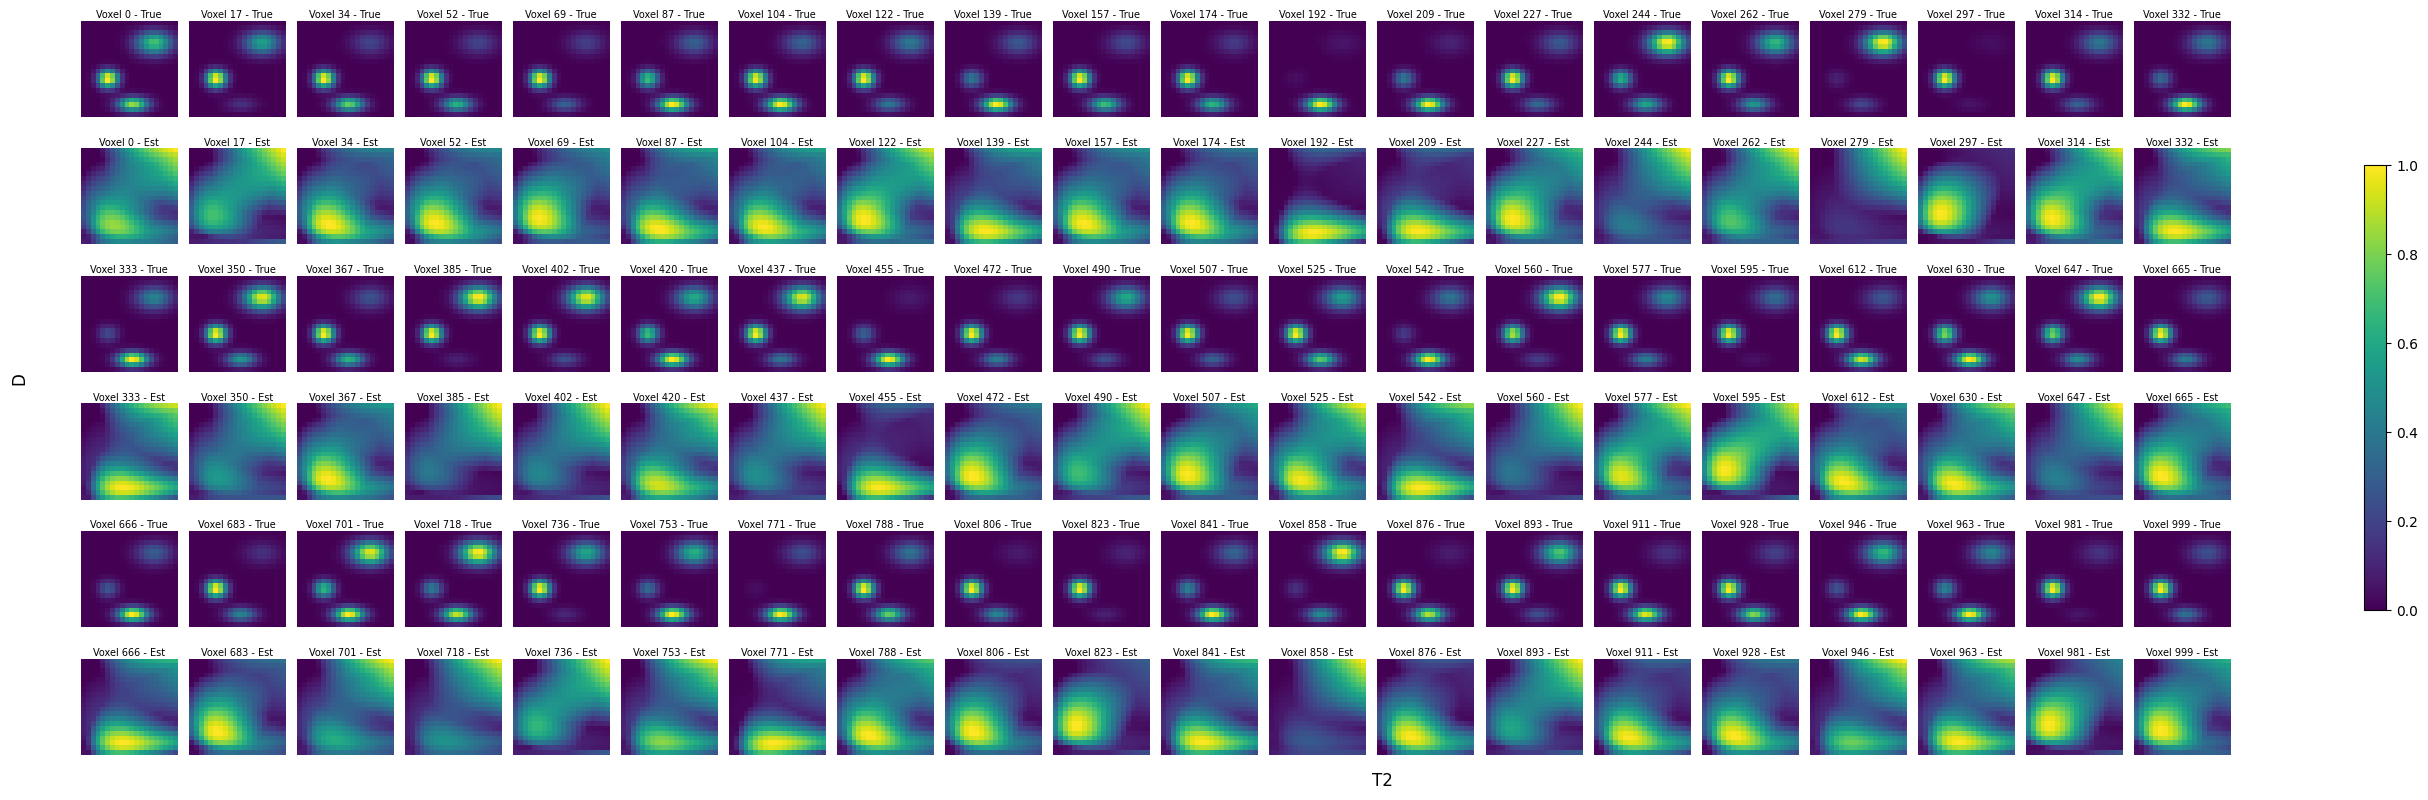

alpha_true= 1.5  W_mae if we just guessed uniform weights: 0.1668

iter 0: loss=31561.0785, fit_err=0.262158, sigma2=0.000004, lam=2.9989, alpha=3.0148
iter 0: loss=31561.4634, fit_err=0.262151, sigma2=0.000004, lam=2.9989, alpha=3.0000
alpha_true= 3.0  GT      C_mae init=0.0000  |  learned: W_mae=0.0044 C_mae=0.0037 alpha_est=3.27  |  fixed: W_mae=0.0042 C_mae=0.0034


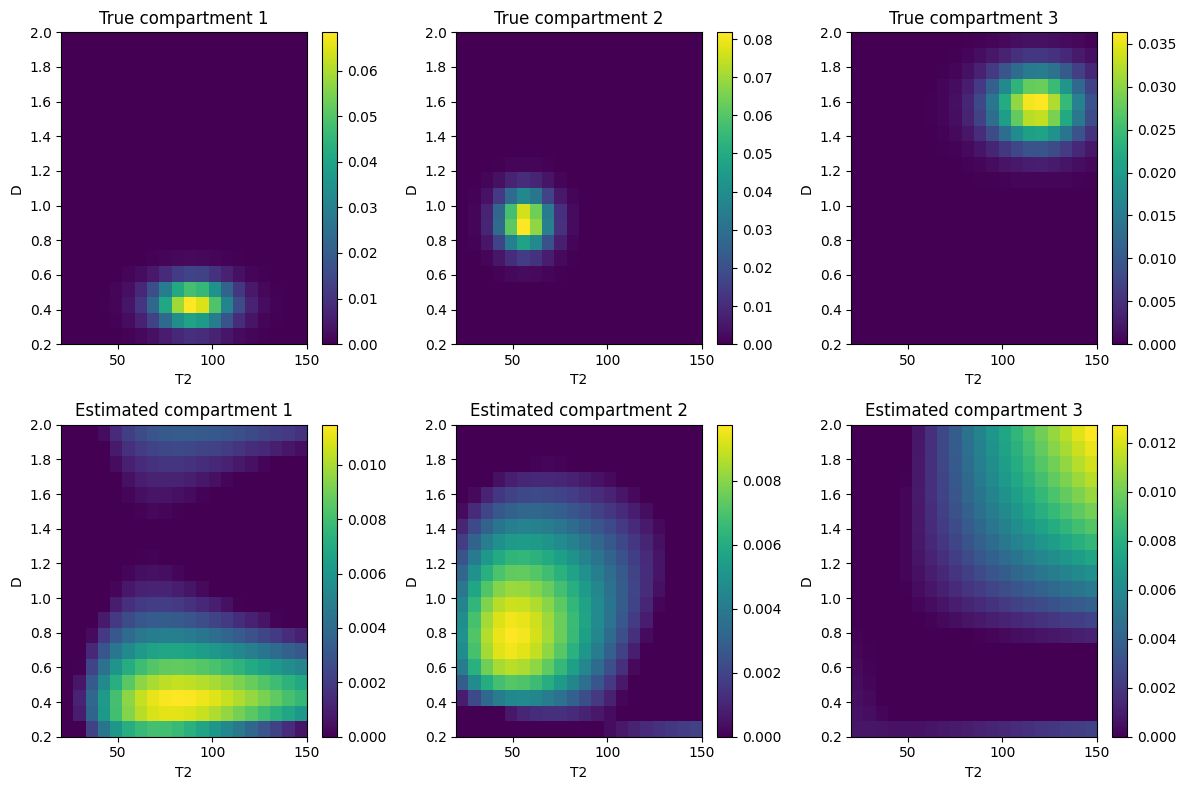

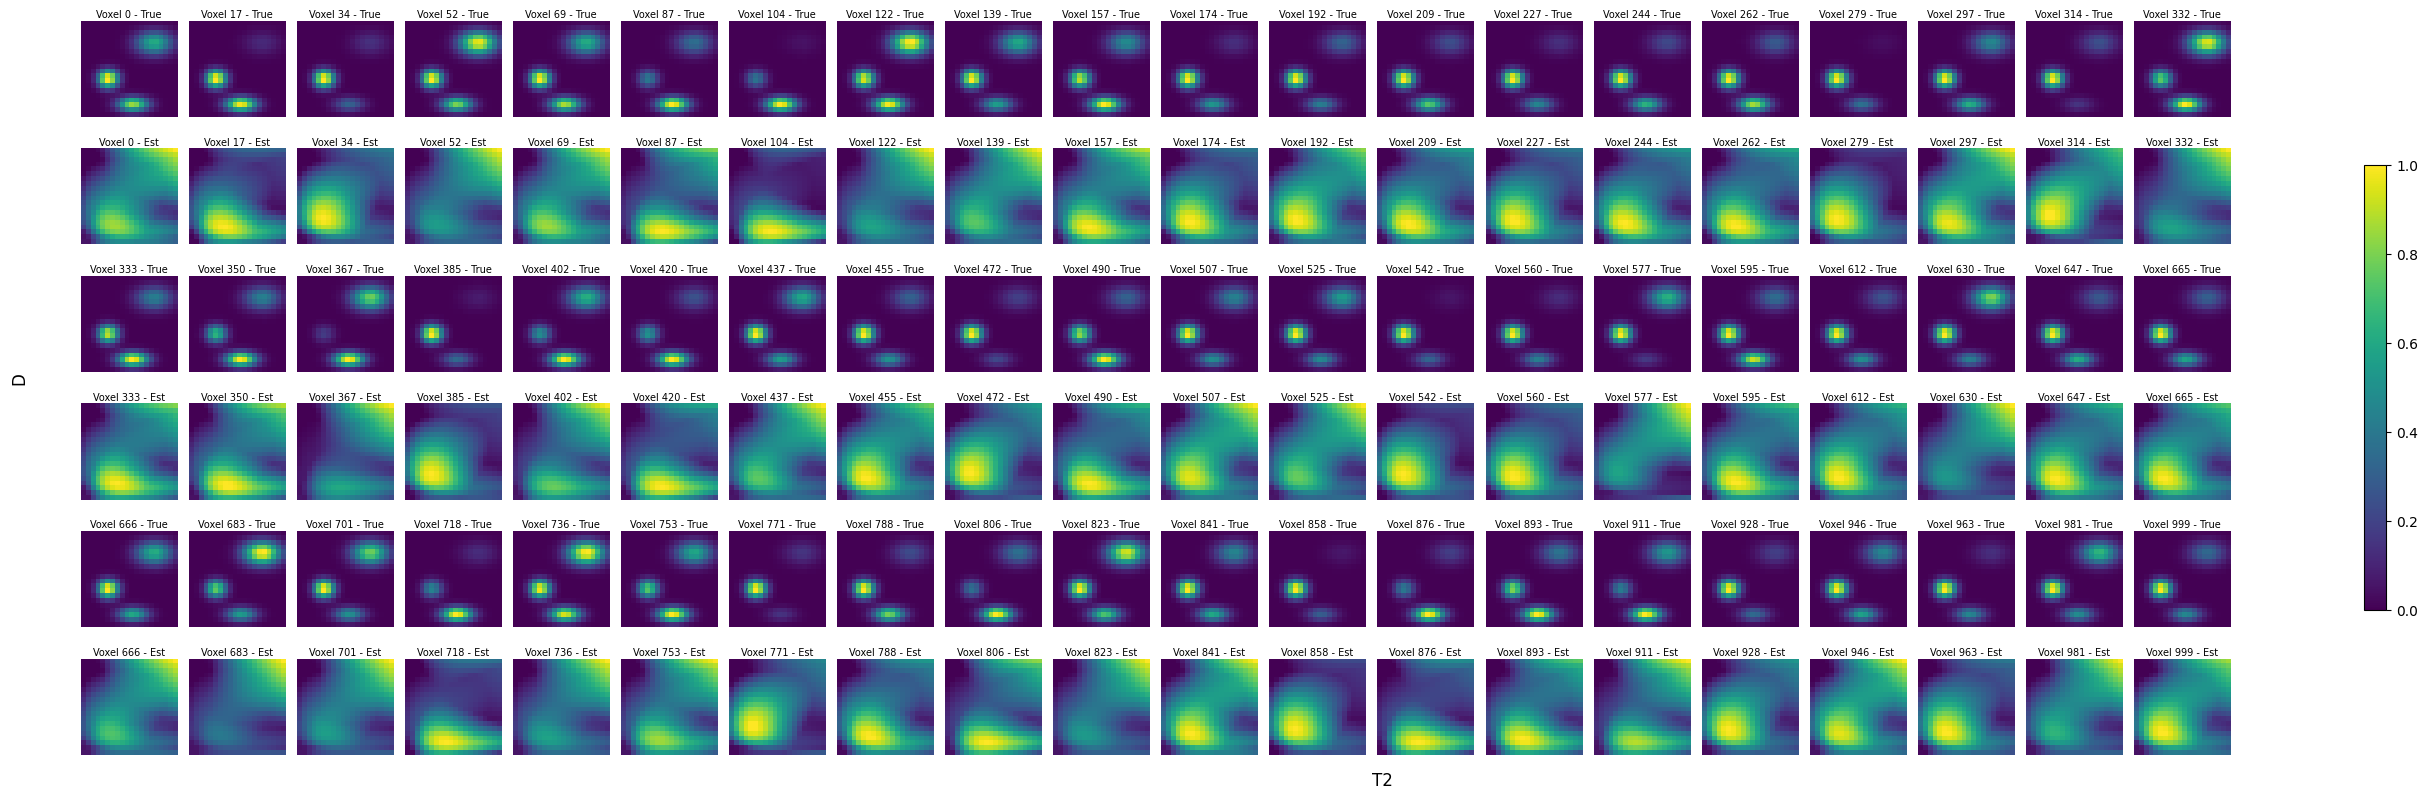

iter 0: loss=1279560.3663, fit_err=10.255794, sigma2=0.000004, lam=3.4665, alpha=0.3175
iter 0: loss=1302861.6474, fit_err=10.360408, sigma2=0.000004, lam=3.4665, alpha=3.0000
alpha_true= 3.0  Lstsq   C_mae init=0.1027  |  learned: W_mae=0.0393 C_mae=0.0191 alpha_est=2.46  |  fixed: W_mae=0.0373 C_mae=0.0184


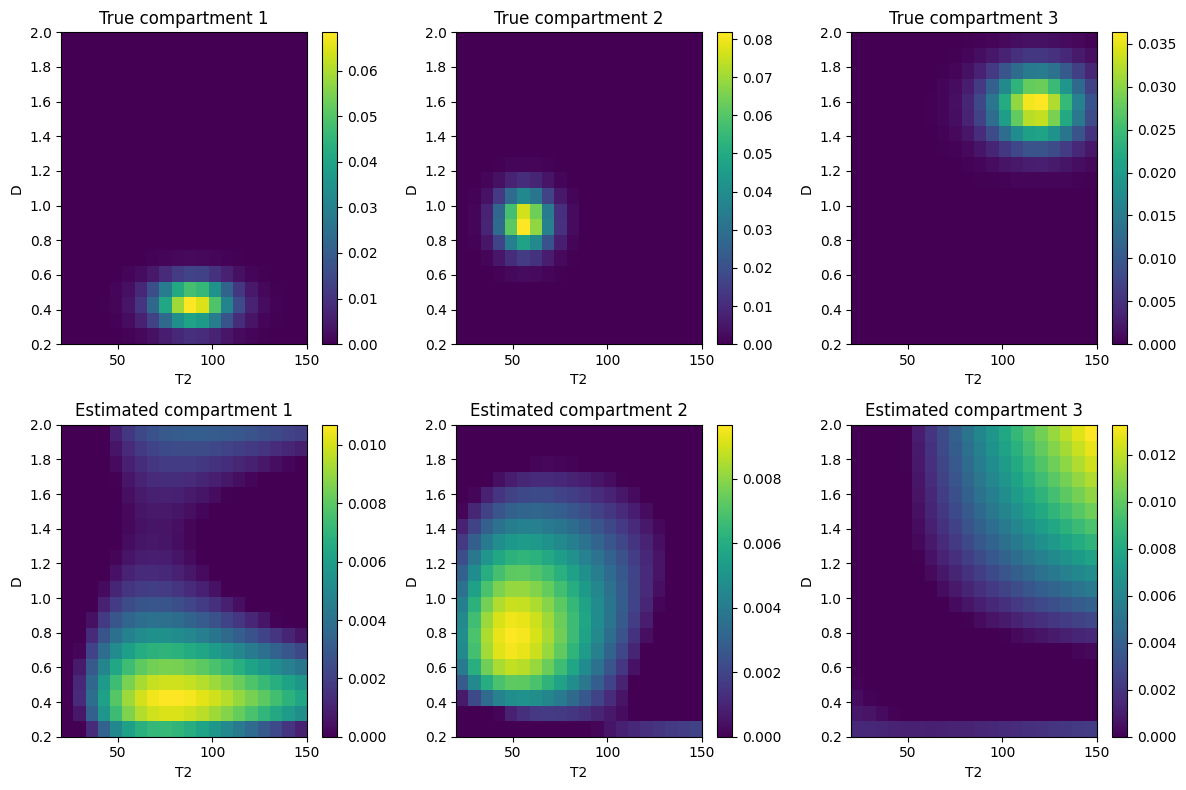

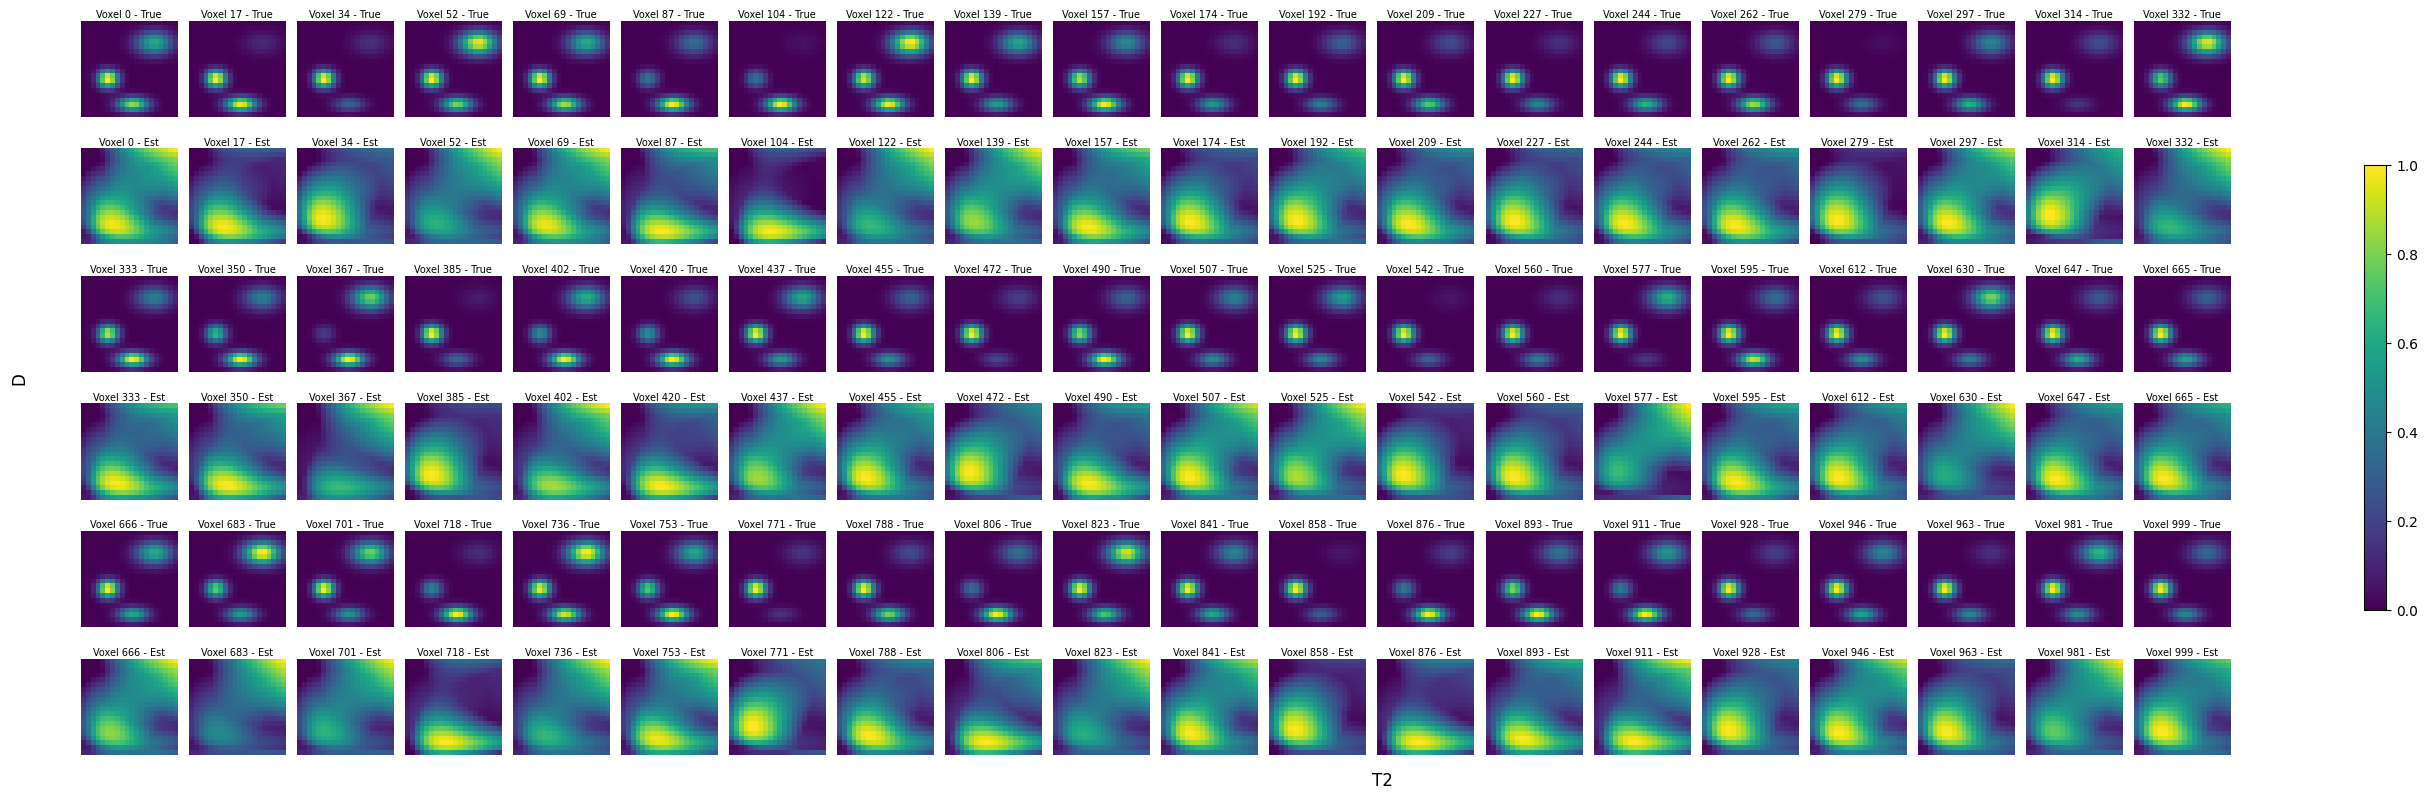

iter 0: loss=33008.4470, fit_err=0.271168, sigma2=0.000004, lam=3.1390, alpha=1.9633
iter 0: loss=33177.2427, fit_err=0.271249, sigma2=0.000004, lam=3.1390, alpha=3.0000
alpha_true= 3.0  NNLS    C_mae init=0.0200  |  learned: W_mae=0.0342 C_mae=0.0166 alpha_est=2.62  |  fixed: W_mae=0.0340 C_mae=0.0166


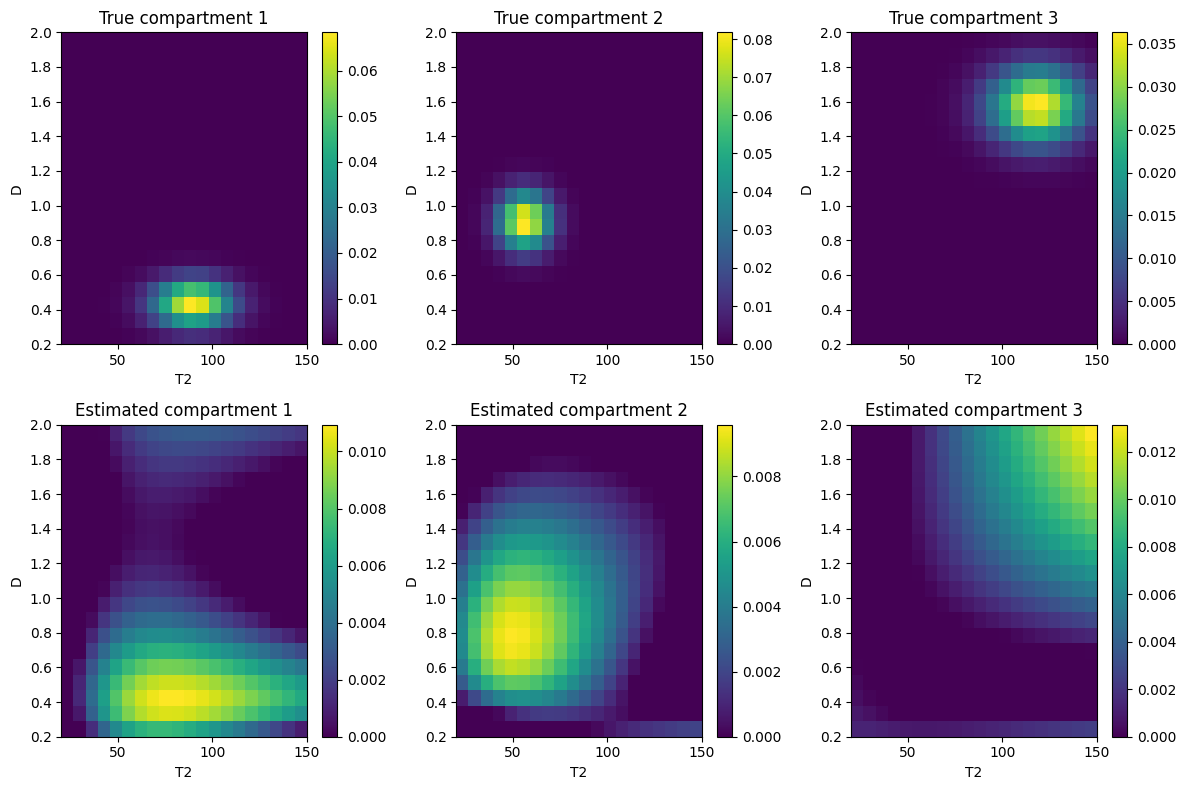

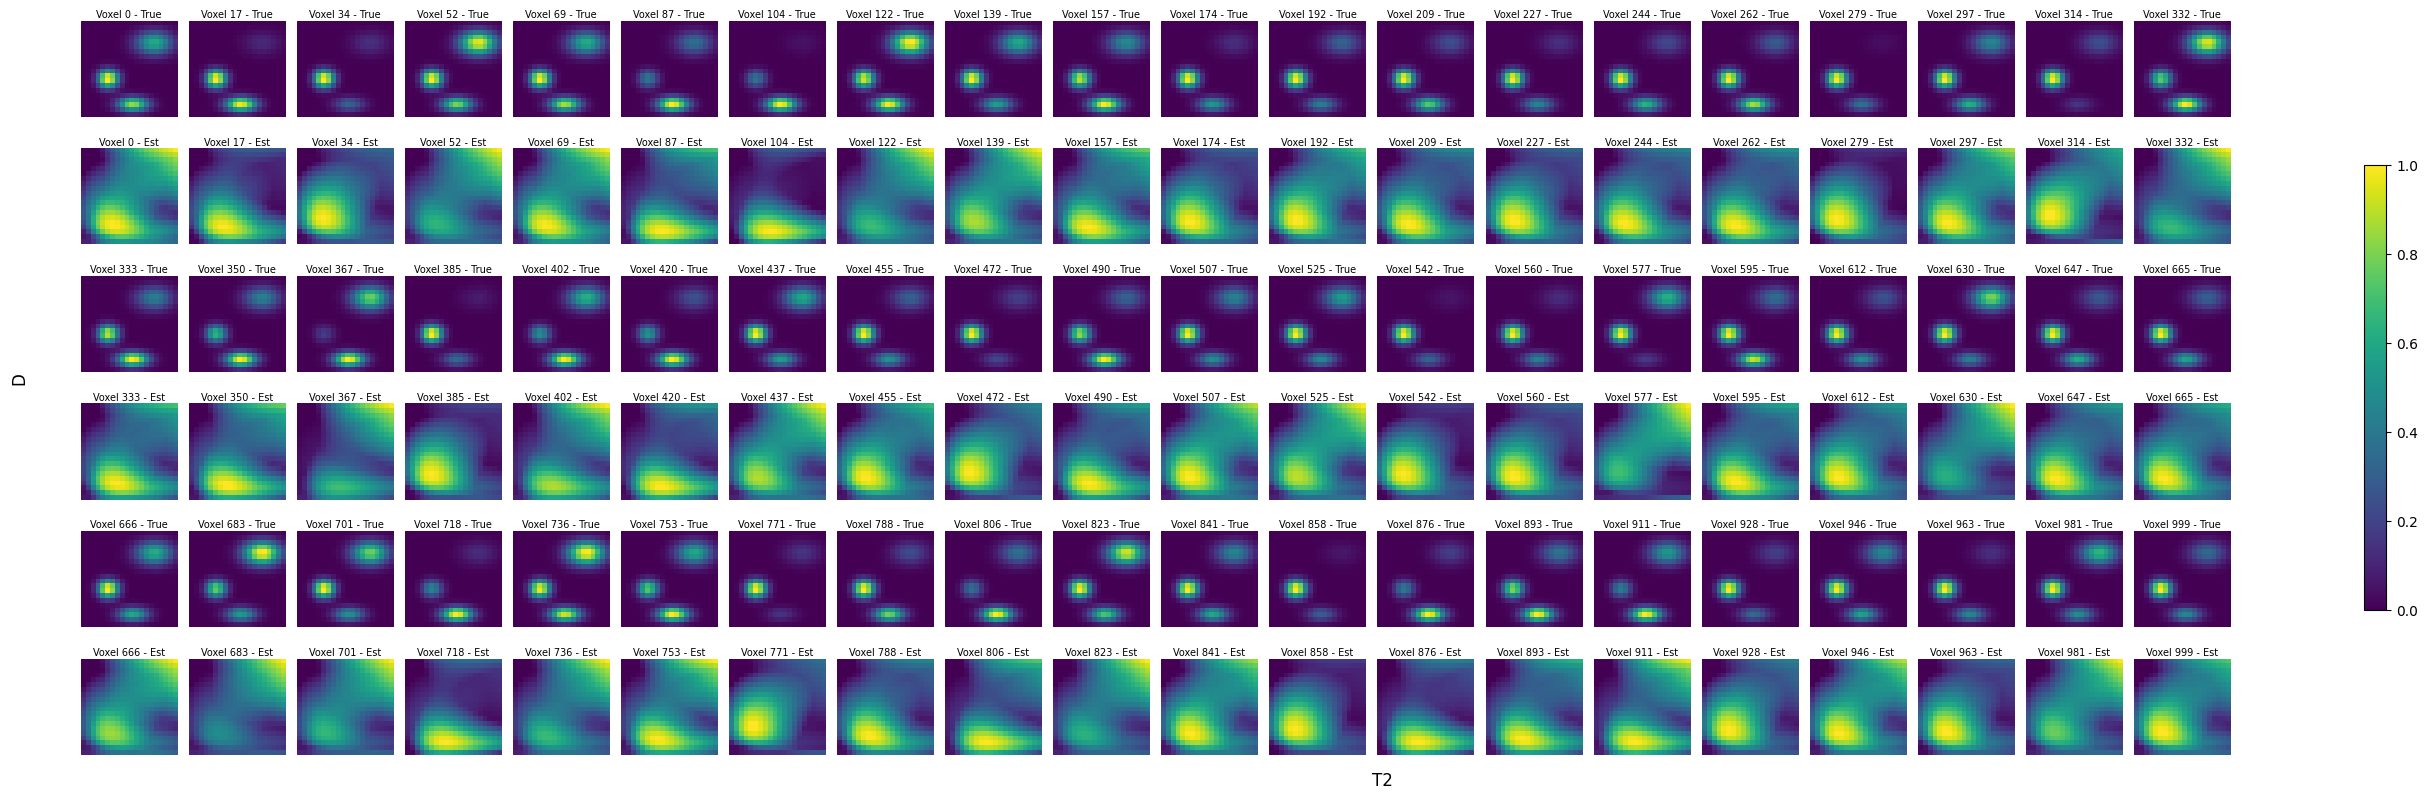

alpha_true= 3.0  W_mae if we just guessed uniform weights: 0.1205

iter 0: loss=31079.9693, fit_err=0.261504, sigma2=0.000004, lam=2.9989, alpha=4.8985
iter 0: loss=31080.2119, fit_err=0.261504, sigma2=0.000004, lam=2.9989, alpha=5.0000
alpha_true= 5.0  GT      C_mae init=0.0000  |  learned: W_mae=0.0052 C_mae=0.0056 alpha_est=5.45  |  fixed: W_mae=0.0050 C_mae=0.0053


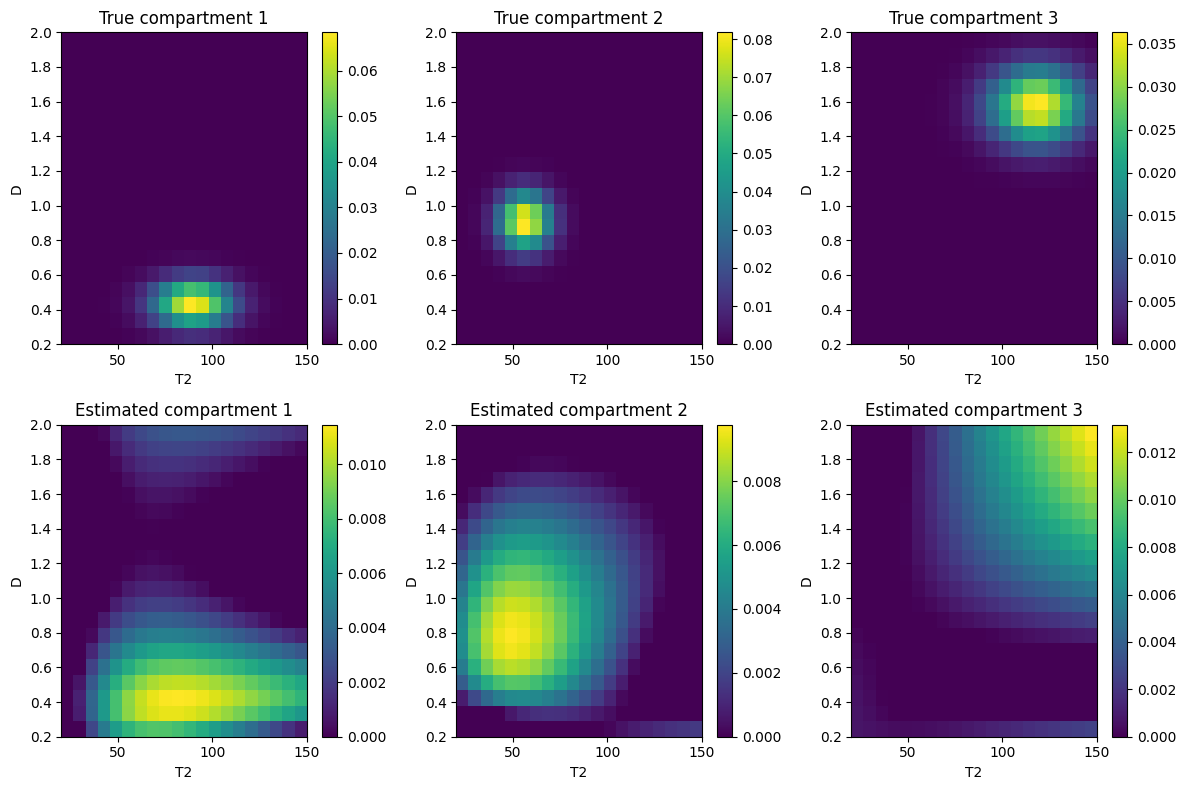

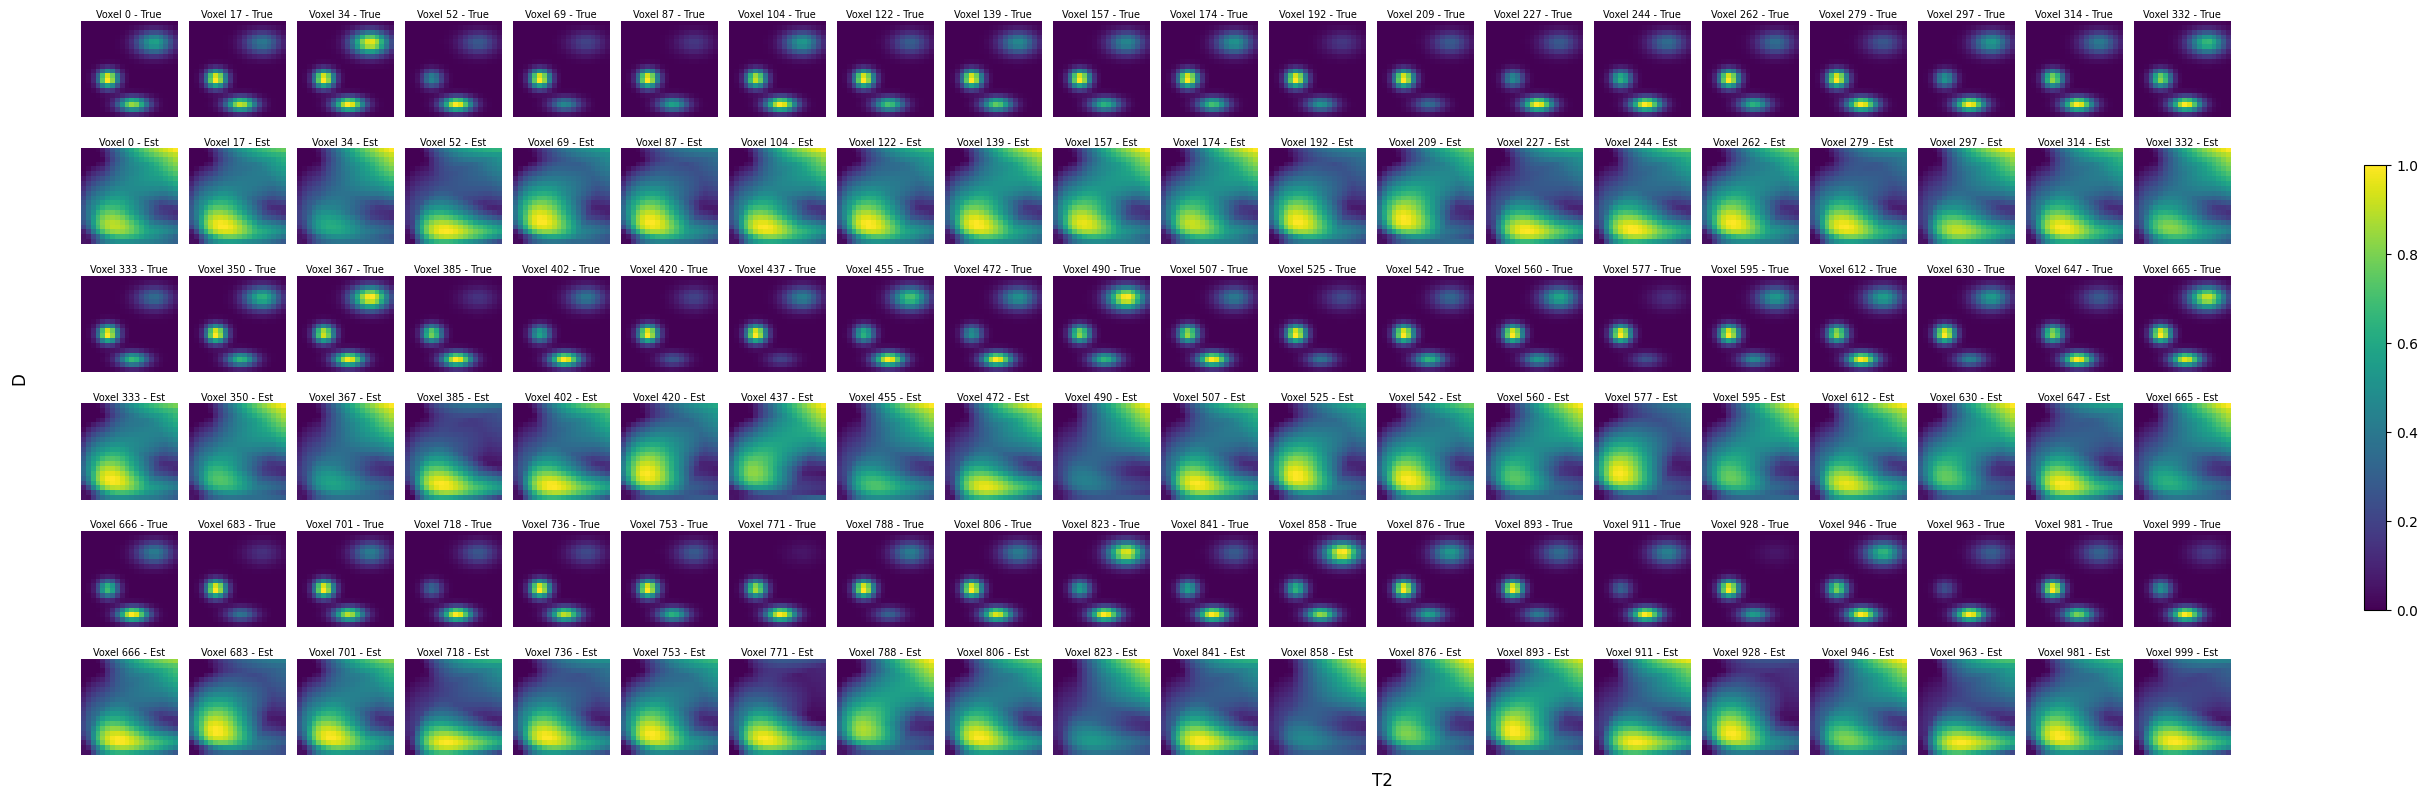

iter 0: loss=1094254.9586, fit_err=8.772817, sigma2=0.000004, lam=3.4399, alpha=0.3236
iter 0: loss=1112834.6895, fit_err=8.772817, sigma2=0.000004, lam=3.4399, alpha=5.0000
alpha_true= 5.0  Lstsq   C_mae init=0.1098  |  learned: W_mae=0.0370 C_mae=0.0214 alpha_est=3.16  |  fixed: W_mae=0.0366 C_mae=0.0205


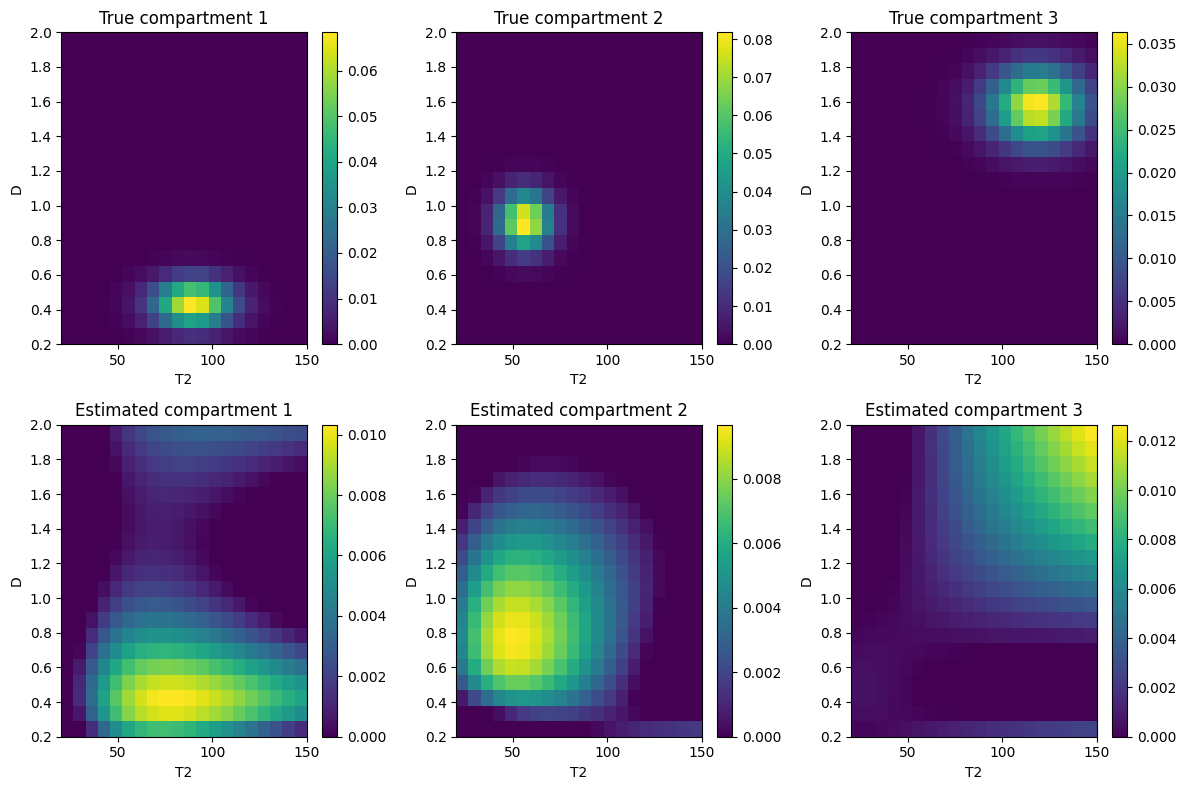

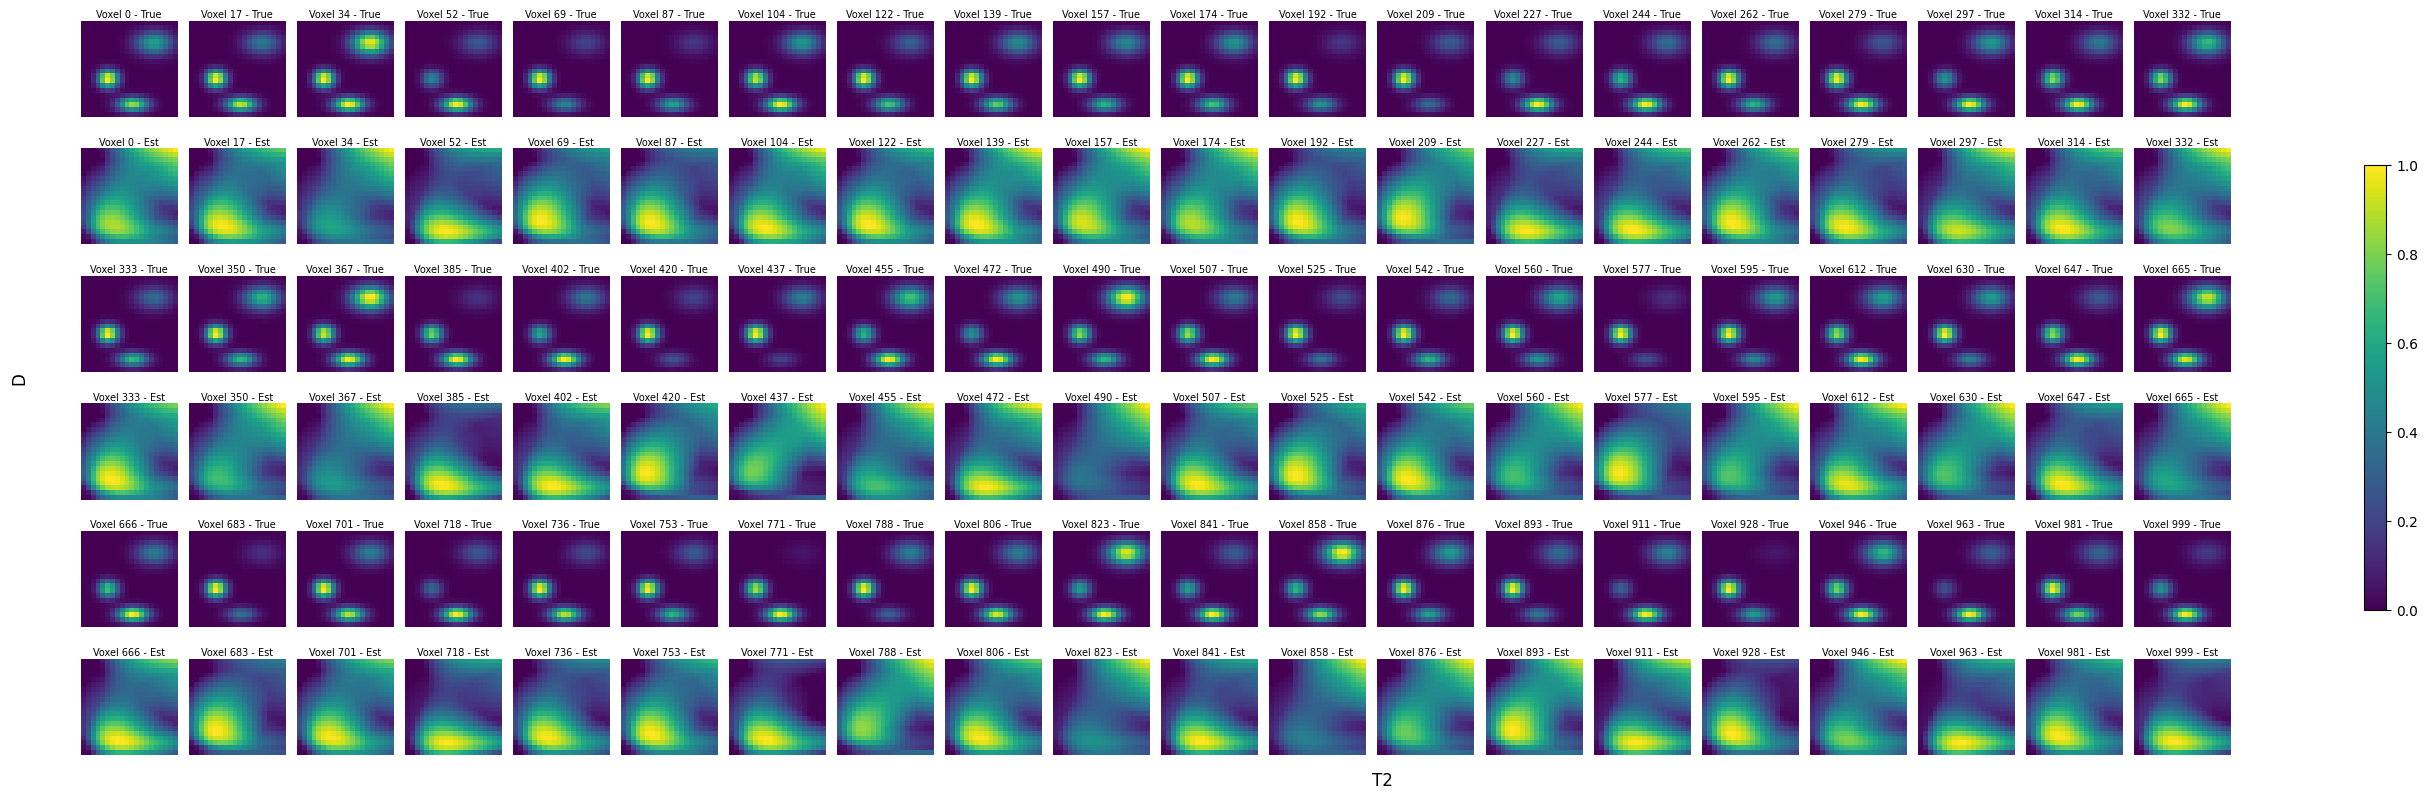

iter 0: loss=32412.0056, fit_err=0.268059, sigma2=0.000004, lam=3.2078, alpha=2.9670
iter 0: loss=32701.4221, fit_err=0.268059, sigma2=0.000004, lam=3.2078, alpha=5.0000
alpha_true= 5.0  NNLS    C_mae init=0.0253  |  learned: W_mae=0.0451 C_mae=0.0168 alpha_est=4.05  |  fixed: W_mae=0.0448 C_mae=0.0167


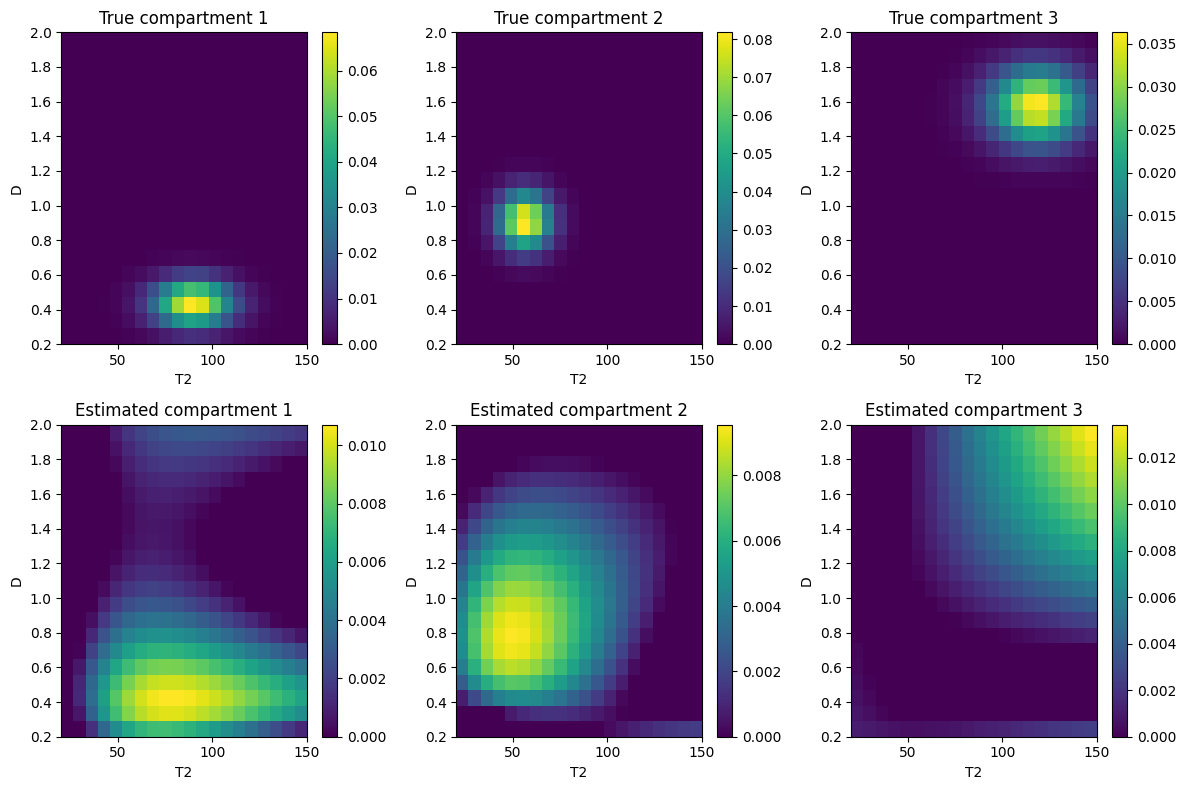

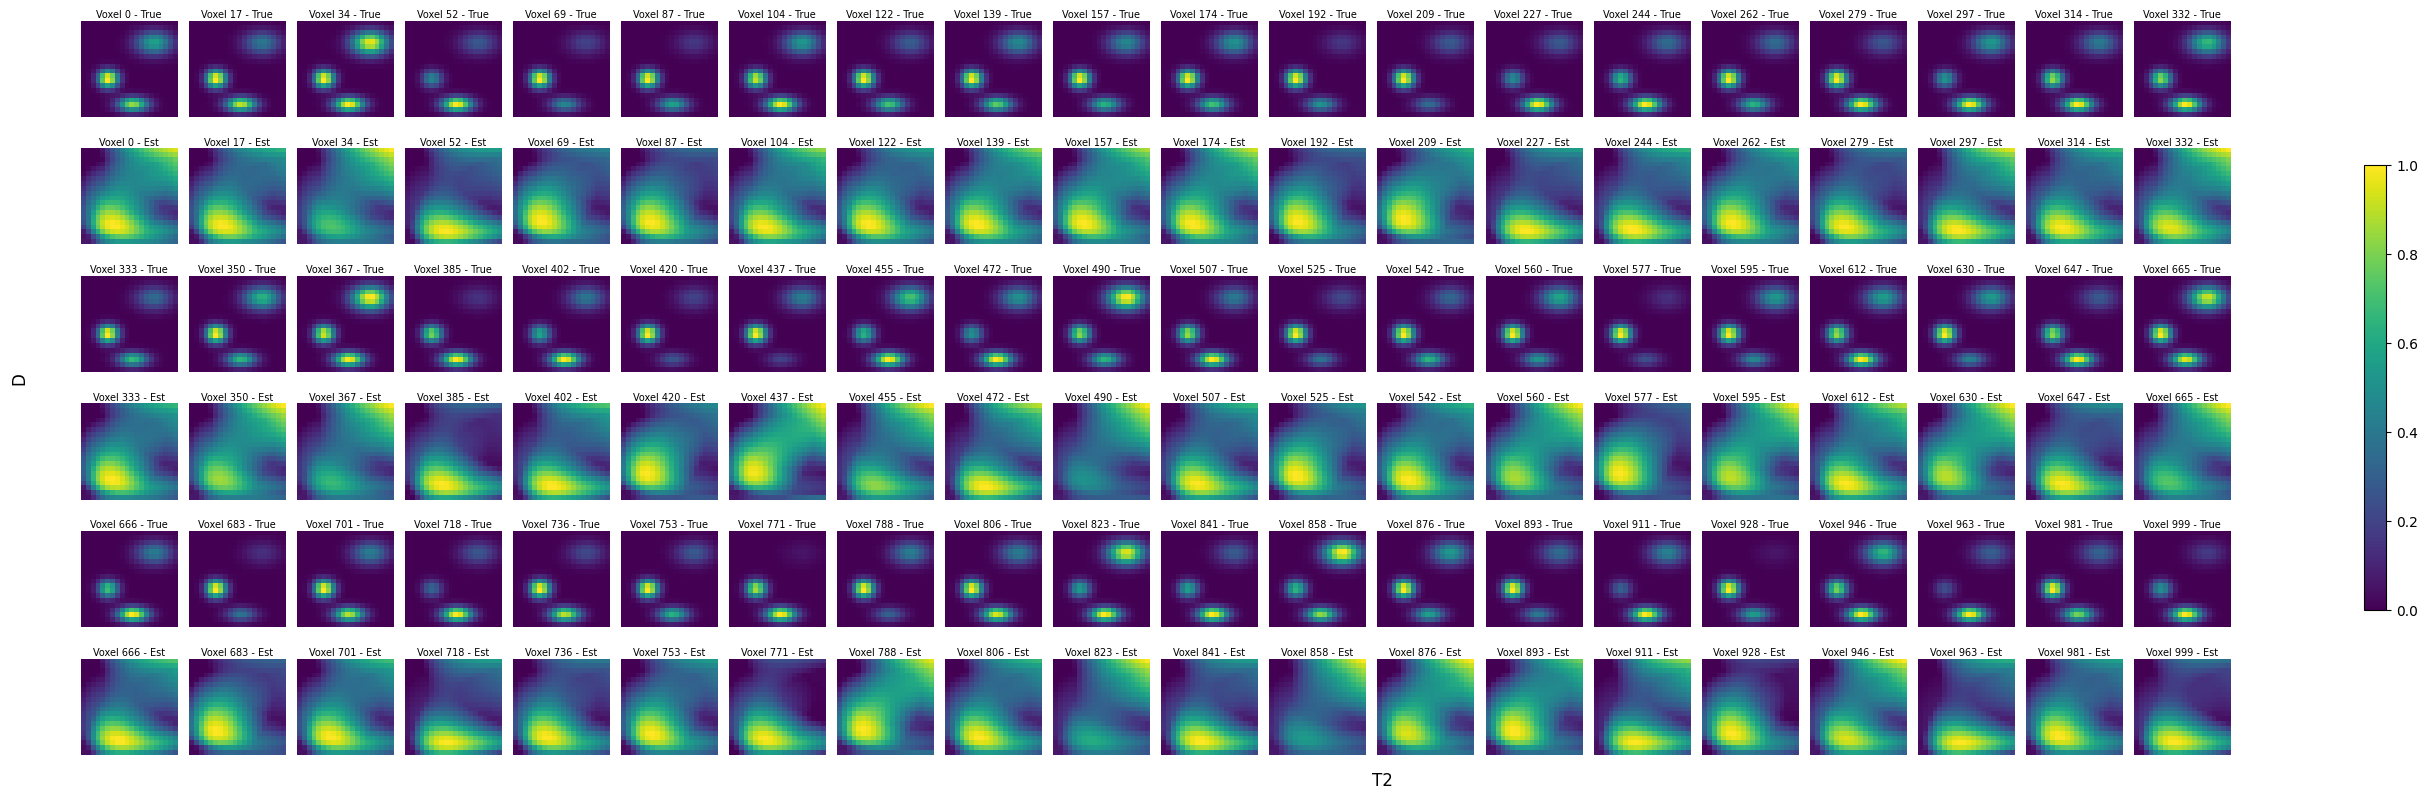

alpha_true= 5.0  W_mae if we just guessed uniform weights: 0.0962



In [9]:
voxel_idx = list(range(n_voxels))
n_iter = 100
alpha_true_values = [1.5, 3.0, 5.0]

for alpha_true_test in alpha_true_values:
    rng_test = np.random.default_rng(1)
    W_true_test = create_W_true(K, n_voxels, alpha_true_test, rng_test)
    Y_test = create_signal(A, C_true, W_true_test, M0_true, sigma_true, rng_test)
    W0_test, _ = define_initial_W_and_m(K, n_voxels, rng_test, alpha_init=5.0)

    C_small_init_gt = C_small_true
    C_small_init_lstsq = define_initial_C_small(Y_test, U, W0_test, M0_true, K)
    C_small_init_nnls = define_initial_C_small_NNLS(
        Y_test, A, s, V_mat, voxel_idx, K, D_vals, T2_vals, Dmin, Dmax, T2min, T2max, nD, nT2,
    )

    for name, C_small_init in [("GT", C_small_init_gt), ("Lstsq", C_small_init_lstsq), ("NNLS", C_small_init_nnls)]:
        lam_init = define_initial_lambda(C_small_init, R, K)

        # alpha learned
        W_est_learn, _, C_small_est_learn, alpha_est_learn, *_ = run_optimisation(
            Y_test, U, C_small_init, M0_true, K, R, eps, n_iter, sigma2_true, 5.0, lam_init, W0_test,
            bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
            update_M0_flag=False, update_C_flag=True,
            verbose_every=n_iter + 1,
        )

        # alpha fixed at the true value
        W_est_fixed, _, C_small_est_fixed, _, *_ = run_optimisation(
            Y_test, U, C_small_init, M0_true, K, R, eps, n_iter, sigma2_true, alpha_true_test, lam_init, W0_test,
            bound_eps=1e-2, update_alpha_flag=False, update_W_flag=True,
            update_M0_flag=False, update_C_flag=True,
            verbose_every=n_iter + 1,
        )

        _, C_mae_init = matched_errors(C_small_true, C_small_init, W_true_test, W0_test)
        W_mae_learn, C_mae_learn = matched_errors(C_small_true, C_small_est_learn, W_true_test, W_est_learn)
        W_mae_fixed, C_mae_fixed = matched_errors(C_small_true, C_small_est_fixed, W_true_test, W_est_fixed)

        print(f"alpha_true={alpha_true_test:4.1f}  {name:6s}  C_mae init={C_mae_init:.4f}  |  "
              f"learned: W_mae={W_mae_learn:.4f} C_mae={C_mae_learn:.4f} alpha_est={alpha_est_learn:.2f}  |  "
              f"fixed: W_mae={W_mae_fixed:.4f} C_mae={C_mae_fixed:.4f}")
        
        C_small_m, W_m = match_components(C_small_true, C_small_est_learn, W_true_test, W_est_learn, K)
        C_est = estimate_C(V_mat, s, C_small_m)
        plot_compartment_comparison(C_true, C_est, K, nD, nT2, D_vals, T2_vals)
        plot_voxel_grid_comparison(C_true, W_true_test, C_est, W_m, K, n_voxels, nD, nT2)


    print(f"alpha_true={alpha_true_test:4.1f}  W_mae if we just guessed uniform weights: {np.mean(np.abs(W_true_test - 1/K)):.4f}\n")


In [10]:
print("n_voxels:", n_voxels, " W_true_test:", W_true_test.shape, " W_est_learn:", W_est_learn.shape, " W_m:", W_m.shape)

n_voxels: 1000  W_true_test: (3, 1000)  W_est_learn: (3, 1000)  W_m: (3, 1000)


## 8. Recovery test on a smaller case

Case with known answers: K = 3, 300 voxels, `alpha_true` = 3. We run the optimiser from each initialisation and check.
The GT row checks the optimiser itself + Lstsq and NNLS don't see the GT

In [11]:
rng_test = np.random.default_rng(7)
n_iter = 100
n_vox_test = 300
alpha_true_test = 3.0

W_true_test = create_W_true(K, n_vox_test, alpha_true_test, rng_test)
M0_test = create_M0_true(0.7, 1.3, n_vox_test, rng_test)
Y_test = create_signal(A, C_true, W_true_test, M0_test, sigma_true, rng_test)
W0_test, _ = define_initial_W_and_m(K, n_vox_test, rng_test, alpha_init=5.0)

C_small_init_gt = C_small_true
C_small_init_lstsq = define_initial_C_small(Y_test, U, W0_test, M0_test, K)
C_small_init_nnls = define_initial_C_small_NNLS(
    Y_test, A, s, V_mat, list(range(n_vox_test)), K, D_vals, T2_vals, Dmin, Dmax, T2min, T2max, nD, nT2,
)

for name, C_small_init in [("GT", C_small_init_gt), ("Lstsq", C_small_init_lstsq), ("NNLS", C_small_init_nnls)]:
    lam_init = define_initial_lambda(C_small_init, R, K)
    W_est_test, _, C_small_est_test, alpha_est_test, *_ = run_optimisation(
        Y_test, U, C_small_init, M0_test, K, R, eps, n_iter, sigma2_true, 5.0, lam_init, W0_test,
        bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
        update_M0_flag=False, update_C_flag=True,
        verbose_every=n_iter + 1,
    )
    W_mae_test, C_mae_test = matched_errors(C_small_true, C_small_est_test, W_true_test, W_est_test)
    alpha_rel_err = abs(alpha_est_test - alpha_true_test) / alpha_true_test

    print(f"{name}: W_mae={W_mae_test:.4f}, C_mae={C_mae_test:.4f}, alpha_est={alpha_est_test:.2f} (true {alpha_true_test})")
    print(f"alpha relative error: {alpha_rel_err }\n")


iter 0: loss=9481.1193, fit_err=0.078568, sigma2=0.000004, lam=2.9989, alpha=2.8366
GT: W_mae=0.0043, C_mae=0.0034, alpha_est=3.05 (true 3.0)
alpha relative error: 0.01714720423577883

iter 0: loss=372123.5403, fit_err=2.982275, sigma2=0.000004, lam=3.4067, alpha=0.3346
Lstsq: W_mae=0.0458, C_mae=0.0213, alpha_est=2.11 (true 3.0)
alpha relative error: 0.29743030163299383

iter 0: loss=9664.7718, fit_err=0.079351, sigma2=0.000004, lam=3.1071, alpha=1.9154
NNLS: W_mae=0.0264, C_mae=0.0132, alpha_est=2.30 (true 3.0)
alpha relative error: 0.23273905422571728



## 9. Estimating M0 and σ² too

So far `M0` and `sigma2` were given as their true values (`M0_true`, `sigma2_true`). With real data neither is known, so here both are estimated as well (`update_M0_flag=True`, `update_sigma2_flag=True`).

- `M0` starts at 1 for every voxel.
- `sigma2` starts from the residual of the initial guess (`update_sigma2` with the starting C, W0 and M0).

Nothing here uses the ground truth except the GT row, which starts C at the truth as before. Section 5 uses the same data and starting points with M0 and σ² given, so the two can be compared. All starting points are rebuilt here without using M0_true or sigma2_true. The GT row still starts C at the truth as an oracle reference. The NNLS start matches section 5, since it doesn't depend on M0; the Lstsq start is built with M0_init instead of M0_true.

Estimating M0 adds a scale ambiguity. Each voxel's weights no longer sum to 1, but after renormalising them, M0 absorbs the factor and the fit is unchanged. So with M0 free, the data no longer fix each compartment's size and the full-grid C columns can drift away from summing to 1. Expect worse W and C than in section 5, even from the GT start. Simply rescaling each C column to sum to 1 after every update is not a fix, in a quick test it made alpha run away (≈ 10).

In [12]:
n_iter = 150
M0_init = np.ones(n_voxels)

C_small_init_gt = C_small_true                                        # oracle reference, as in section 5
C_small_init_lstsq = define_initial_C_small(Y, U, W0, M0_init, K)     # built without the true M0
C_small_init_nnls = define_initial_C_small_NNLS(
    Y, A, s, V_mat, init_voxel_idx, K, D_vals, T2_vals, Dmin, Dmax, T2min, T2max, nD, nT2,
)                              # same NNLS start as section 5  

for name, C_small_init in [("GT", C_small_init_gt), ("Lstsq", C_small_init_lstsq), ("NNLS", C_small_init_nnls)]:
    lam_init = define_initial_lambda(C_small_init, R, K)
    sigma2_init = update_sigma2(Y, U @ C_small_init, W0, M0_init)

    W_est_all, M0_est_all, C_small_est_all, alpha_est_all, sigma2_est_all, *_ = run_optimisation(
        Y, U, C_small_init, M0_init, K, R, eps, n_iter, sigma2_init, 5.0, lam_init, W0,
        bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
        update_M0_flag=True, update_C_flag=True, update_sigma2_flag=True,
        verbose_every=n_iter + 1,
    )

    W_mae_all, C_mae_all = matched_errors(C_small_true, C_small_est_all, W_true, W_est_all)
    M0_rel_err = np.mean(np.abs(M0_est_all - M0_true) / M0_true)

    print(f"{name}: W_mae={W_mae_all:.4f}, C_mae={C_mae_all:.4f}, alpha_est={alpha_est_all:.2f} (true {alpha_true})")
    print(f"   M0 relative error={M0_rel_err:.4f},  sigma2_est={sigma2_est_all:.2e} (true {sigma2_true:.2e}, start {sigma2_init:.2e})\n")


iter 0: loss=31114.9037, fit_err=3.745673, sigma2=0.000059, lam=2.9989, alpha=1.8690
GT: W_mae=0.0268, C_mae=0.0194, alpha_est=2.77 (true 3.0)
   M0 relative error=0.0152,  sigma2_est=4.03e-06 (true 4.00e-06, start 1.95e-03)

iter 0: loss=31145.4758, fit_err=20.248824, sigma2=0.000316, lam=3.4467, alpha=1.8169
Lstsq: W_mae=0.1081, C_mae=0.1420, alpha_est=5.77 (true 3.0)
   M0 relative error=0.0471,  sigma2_est=4.02e-06 (true 4.00e-06, start 1.63e-03)

iter 0: loss=31166.8009, fit_err=3.909349, sigma2=0.000061, lam=3.0117, alpha=1.7042
NNLS: W_mae=0.0315, C_mae=0.0212, alpha_est=2.71 (true 3.0)
   M0 relative error=0.0143,  sigma2_est=4.03e-06 (true 4.00e-06, start 1.91e-03)



### Summary: what works and what doesn't yet

**Works**
- Started from the true C, it recovers W, C and alpha (GT rows in sections 5, 7 and 8). The unit tests in `tests/` (41) all pass.
- The fit reaches the noise level
- The alpha feedback loop is not the main source of error at σ = 0.002. Fixing alpha at its true value changes W error only slightly (section 7).
- NNLS initialisation gives a much better starting C than least squares, provided the averaged NNLS spectrum uses enough voxels (50 voxels in section 5, all voxels in sections 7 and 8).  With too few, the k-means step can merge two compartments
- W from data-driven starts is clearly better than guessing uniform weights (section 7)

Doesn't work yet
- From a data-driven start, W and C are not fully recovered. C and W can trade off without changing the fit, so the Dirichlet prior can push W toward uniform and alpha upward while C compensates.
- Data-driven starts don't pass the recovery test in section 8
- alpha is biased and at higher noise it can run away (e.g. ≈ 10 instead of 1.5 at σ = 0.02).
- Sections 3-8 use the true M0 and σ². Section 9 estimates both. In that test, W MAE from the GT start rose from ≈ 0.007 to ≈ 0.03 and the estimated compartment spectra no longer sum to 1, because M0 can absorb their scale. There is no tested fix yet.

Next steps is to constrain C: require a non-negative full-grid spectrum, parametrise each compartment as a Gaussian blob?


## 10. Automated tests

The core functions demonstrated above are unit-tested in `tests/`:

- `tests/test_create_grid.py` - grid construction, forward model, SVD compression, ground-truth simulation
- `tests/test_optimiser_alpha_gamma.py` — the full optimisation loop
- `tests/test_plotting.py` — the permutation-matching logic used to compute recovery error

Run the whole suite with:

```bash
python3 -m pytest tests/ -v
```

## Project structure

```
create_grid.py               # forward model, ground-truth simulation
optimiser_alpha_gamma.py   # Bayesian optimiser
plotting.py                  # visualisation + permutation-matched error metrics
tests/                       # pytest suite for the three modules above
demo_pipeline.ipynb          # this notebook
```